# Design of Sparse Control for Network Opinion Manipulation

EE4740 project. We solve for piecewise-sparse control inputs that drive a 25-node opinion network from a zero initial state to given target states, under a per-step actuation budget on the external manipulator.

In [1]:
%matplotlib inline
# setup: imports, project paths, seed
from pathlib import Path
import numpy as np
import scipy.io
import matplotlib.pyplot as plt

# resolve the project root whether the kernel starts in notebooks/ or the project root
ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
DATA = ROOT / 'data' / 'PiecewiseSparse.mat'
FIGS = ROOT / 'figures'
FIGS.mkdir(exist_ok=True)

N = 25                      # network size and number of control steps
rng = np.random.default_rng(42)
np.random.seed(42)
plt.rcParams['figure.dpi'] = 110

## Problem formulation

The network has 25 nodes with opinion vector $x_k$ evolving as $x_{k+1} = A x_k + u_k$, where $u_k$ is the external control applied at step $k$ and the manipulator can in principle reach any node ($B = I$). Over $N = 25$ steps the final state is $x_N = A^N x_0 + \sum_{k=1}^{N} A^{N-k} u_k$. Writing $b = x_N - A^N x_0$ and stacking the controls as $u = [u_1; \dots; u_N] \in \mathbb{R}^{625}$ turns the schedule into a single linear system $b = \Phi u$ with $\Phi = [\,A^{N-1} \mid A^{N-2} \mid \dots \mid A \mid I\,]$ of size $25 \times 625$. Block $k$ of $\Phi$ multiplies the control $u_k$, so the earliest control sees the highest power of $A$.

The control is piecewise sparse. Each block $u_k$ may activate at most $s$ nodes, so $u$ has 25 blocks of length 25 with at most $s$ nonzeros per block. This is not block sparsity. Every block is allowed to be active and only the number of active nodes within a single step is capped. With 25 equations and up to $25s$ nonzeros the system is far underdetermined, and even $s = 1$ leaves up to 25 free coefficients drawn from a 25-row dictionary, which is already enough to reach any 25-dimensional target. Feasibility is therefore not the hard part. The real questions are how the control energy trades off against the budget $s$, where in time the control concentrates, and whether exploiting the per-block structure helps recovery.

In [2]:
m = scipy.io.loadmat(DATA)
A = m['A']
FinalState = m['FinalState']
print('A shape', A.shape, '| FinalState shape', FinalState.shape)

# basic character of A
ev = np.linalg.eigvals(A)
rho = np.max(np.abs(ev))
row_sums = A.sum(axis=1)
print('A entry range: [%.3f, %.3f]' % (A.min(), A.max()))
print('A symmetric:', np.allclose(A, A.T))
print('row-sum range: [%.3f, %.3f]  (row-stochastic would be all 1)' % (row_sums.min(), row_sums.max()))
print('spectral radius rho(A) = %.4f' % rho)
print('largest |Im(eig)| = %.3f  (A has complex eigenvalues)' % np.max(np.abs(ev.imag)))

# targets
bnorms = np.linalg.norm(FinalState, axis=1)
print('target norms ||b||: min %.3f, mean %.3f, max %.3f' % (bnorms.min(), bnorms.mean(), bnorms.max()))

A shape (25, 25) | FinalState shape (1000, 25)
A entry range: [-3.160, 3.113]
A symmetric: False
row-sum range: [-7.156, 11.011]  (row-stochastic would be all 1)
spectral radius rho(A) = 6.0778
largest |Im(eig)| = 3.564  (A has complex eigenvalues)
target norms ||b||: min 3.164, mean 4.966, max 7.178


The matrix $A$ is a dense real $25 \times 25$ matrix with signed entries in $[-3.16, 3.11]$. It is not symmetric and not row stochastic: the row sums run from $-7.16$ to $11.01$, so $A$ is not an averaging or consensus operator. Its spectral radius is $6.08$, well above one, so the open-loop dynamics are unstable and powers of $A$ grow geometrically. $A$ also has complex eigenvalues, with imaginary parts up to $3.56$, so the system oscillates while it diverges. The 1000 target states have norms between $3.16$ and $7.18$, the same order as the entries of $A$, so the targets carry no large scale of their own. Any blow-up in the problem will come from $\Phi$.

In [3]:
# Phi = [A^(N-1) | A^(N-2) | ... | A | I]; block j holds A^(N-1-j)
powers = [N - 1 - j for j in range(N)]            # 24, 23, ..., 0
Phi = np.hstack([np.linalg.matrix_power(A, p) for p in powers])
print('Phi shape', Phi.shape)

col_norms = np.linalg.norm(Phi, axis=0)           # column 2-norms = the scale vector
sv_raw = np.linalg.svd(Phi, compute_uv=False)
print('cond(Phi_raw) = %.2e' % (sv_raw[0] / sv_raw[-1]))

block = np.arange(Phi.shape[1]) // N              # block index of each column
print('median column norm by block (block 0 = A^%d ... block %d = I):' % (N - 1, N - 1))
for j in [0, 6, 12, 18, 23, 24]:
    cn = col_norms[block == j]
    print('  block %2d (A^%2d): %.2e' % (j, N - 1 - j, np.median(cn)))

Phi shape (25, 625)
cond(Phi_raw) = 5.14e+16
median column norm by block (block 0 = A^24 ... block 24 = I):
  block  0 (A^24): 2.55e+18
  block  6 (A^18): 4.92e+13
  block 12 (A^12): 1.04e+09
  block 18 (A^ 6): 2.34e+04
  block 23 (A^ 1): 4.92e+00
  block 24 (A^ 0): 1.00e+00


Stacking the matrix powers makes the scale problem explicit. The earliest control block is $A^{24}$, whose columns have norm on the order of $10^{18}$, while the last block is the identity with columns of norm exactly $1$. The median column norm falls smoothly from $2.5 \times 10^{18}$ in block 0 to $1$ in the identity block, spanning about eighteen orders of magnitude. The condition number of the raw dictionary is $5 \times 10^{16}$, effectively singular in double precision. This is a pure scaling effect of $\rho(A) = 6.08$ raised to the 24th power, not a sign that the control problem itself is ill posed. Both greedy correlation and least squares break on the raw dictionary. Correlations $|\Phi^\top r|$ would be dominated by the giant early-time columns regardless of relevance, and a least squares solve at this condition number returns noise.

cond(Phi_norm) = 16.67
cond(last 5 blocks, normalized) = 4.78


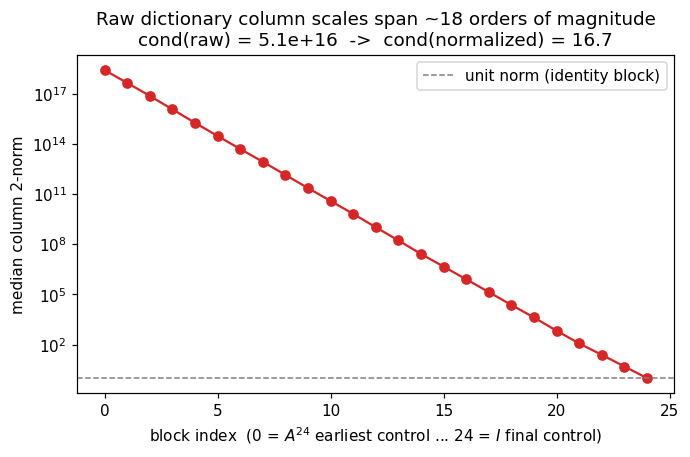

In [4]:
# normalize every column to unit norm; keep the scale vector to undo it later
Phi_n = Phi / col_norms
sv_n = np.linalg.svd(Phi_n, compute_uv=False)
cond_n = sv_n[0] / sv_n[-1]
last5 = Phi_n[:, (N - 5) * N:]                     # blocks 20..24 = A^4 ... I
sv5 = np.linalg.svd(last5, compute_uv=False)
print('cond(Phi_norm) = %.2f' % cond_n)
print('cond(last 5 blocks, normalized) = %.2f' % (sv5[0] / sv5[-1]))

# figure: per-block column scale before normalization
med_by_block = np.array([np.median(col_norms[block == j]) for j in range(N)])
fig, ax = plt.subplots(figsize=(7, 4))
ax.semilogy(range(N), med_by_block, 'o-', color='C3')
ax.axhline(1.0, ls='--', color='gray', lw=1, label='unit norm (identity block)')
ax.set_xlabel('block index  (0 = $A^{24}$ earliest control ... 24 = $I$ final control)')
ax.set_ylabel('median column 2-norm')
ax.set_title('Raw dictionary column scales span ~18 orders of magnitude\n'
             'cond(raw) = %.1e  ->  cond(normalized) = %.1f' % (sv_raw[0] / sv_raw[-1], cond_n))
ax.legend()
plt.savefig(FIGS / 'phi_column_scales.png', dpi=150, bbox_inches='tight')
plt.show()

Normalizing every column to unit norm and storing the scale vector fixes the conditioning. The normalized dictionary has condition number $16.7$, and the last five blocks on their own sit at $4.78$, so the recovery problem is well behaved once the artificial scale is removed. We run every solver on the normalized dictionary and rescale the recovered coefficients back to physical units before reporting any energy or residual, since normalization changes the numerical meaning of each coefficient but not the underlying control. The alternative of row equilibration would balance the equations rather than the atoms and would leave the per-column imbalance that drives greedy selection, so column normalization is the right choice here, and it matches the unit-norm convention used throughout the piecewise recovery literature.

In [5]:
# why the scale matters in practice: which block does the first greedy atom fall
# in, on the raw vs the normalized dictionary, across 100 targets (x0 = 0 so b = target)
raw_first  = np.array([block[np.argmax(np.abs(Phi.T   @ FinalState[i]))] for i in range(100)])
norm_first = np.array([block[np.argmax(np.abs(Phi_n.T @ FinalState[i]))] for i in range(100)])
print('raw dictionary: first pick in block 0 (A^24) for %d/100 targets' % int(np.sum(raw_first == 0)))
print('normalized: first pick spans blocks %d-%d, %.0f%% in the identity block'
      % (norm_first.min(), norm_first.max(), 100 * np.mean(norm_first == N - 1)))
ratio = np.abs(Phi.T @ FinalState[0])[block == 0].max() / np.abs(Phi.T @ FinalState[0])[block == N - 1].max()
print('target 0: raw correlation is %.0e larger in block 0 than in the identity block' % ratio)

raw dictionary: first pick in block 0 (A^24) for 100/100 targets
normalized: first pick spans blocks 14-24, 31% in the identity block
target 0: raw correlation is 5e+17 larger in block 0 than in the identity block


The effect is direct. On the raw dictionary the first atom selected is in block 0, the $A^{24}$ block, for all 100 targets, because its columns produce correlations about $5 \times 10^{17}$ times larger than the identity block no matter how well they actually match the target. After normalization the first atom is chosen on merit and falls in the late, low-power blocks instead, between block 14 and block 24, with about a third of them in the identity block. Normalization is what lets greedy selection respond to relevance rather than to raw column scale, and that is the reason recovery works at all on this dictionary.

In [6]:
# With only A and FinalState provided we take x0 = 0, so b = FinalState[i].
# (Modelling assumption to confirm with the consultant; a nonzero x0 would
# shift b by A^N x0, a term of order 1e18 that would dominate everything.)
B_targets = FinalState

# Minimal greedy solver with a per-block budget s, on the one shared system
# (not N separate solves). Returns the support, the coefficients rescaled to
# physical units, and the residual.
def greedy_recover(b, s, tol=1e-10, max_atoms=N):
    active = np.ones(Phi_n.shape[1], dtype=bool)
    per_block = np.zeros(N, dtype=int)
    support, coef = [], np.zeros(0)
    r = b.astype(float).copy()
    bnrm = np.linalg.norm(b)
    for _ in range(max_atoms):
        corr = Phi_n.T @ r
        corr[~active] = 0.0
        j = int(np.argmax(np.abs(corr)))
        if abs(corr[j]) < 1e-14:
            break
        support.append(j)
        per_block[block[j]] += 1
        if per_block[block[j]] >= s:               # budget hit, drop rest of this block
            active[block == block[j]] = False
        coef, *_ = np.linalg.lstsq(Phi_n[:, support], b, rcond=None)
        r = b - Phi_n[:, support] @ coef
        if np.linalg.norm(r) <= tol * bnrm:
            break
    coef_phys = coef / col_norms[support]          # rescale back to physical units
    return support, coef_phys, np.linalg.norm(r)

for s in (1, 2):
    sup, coef, res = greedy_recover(B_targets[0], s)
    print('target 0, s=%d: %d atoms, residual %.2e, control energy ||u|| = %.3f'
          % (s, len(sup), res, np.linalg.norm(coef)))

for s in (1, 2):
    res_med = np.median([greedy_recover(B_targets[i], s)[2] for i in range(100)])
    print('median residual over 100 targets, s=%d: %.2e' % (s, res_med))

target 0, s=1: 25 atoms, residual 2.18e-10, control energy ||u|| = 8.599
target 0, s=2: 25 atoms, residual 2.39e-13, control energy ||u|| = 4.677


median residual over 100 targets, s=1: 6.71e-10
median residual over 100 targets, s=2: 3.13e-13


With only $A$ and the final states in the dataset, the one self-consistent reading is $x_0 = 0$, which makes $b$ equal to the given FinalState row. A nonzero initial state would add $A^N x_0$ to $b$, a term of order $10^{19}$ that would swamp the target, so we take $x_0 = 0$ and flag this as the single modelling assumption to confirm with the consultant. A short greedy solve on the normalized dictionary confirms the degrees-of-freedom argument. At $s = 1$ the first target is recovered to residual $2 \times 10^{-10}$ using 25 atoms, and the median residual over 100 targets is $7 \times 10^{-10}$. At $s = 2$ the residual drops to about $10^{-13}$. The squared residual is then on the order of $10^{-20}$, far below the success threshold $\xi = 10^{-2}\,\lVert b\rVert_2^2$ (about 0.1 to 0.5 for these targets) that the later experiments use to call a target feasible, so the recovery is exact for any sensible tolerance. A budget of one active node per step is already enough to reach any target essentially exactly, consistent with the count of 25 equations against up to 25 nonzeros and with the theory that a minimum number of active inputs, not a large per-step budget, governs controllability. The recovered energy falls from $8.6$ at $s = 1$ to $4.7$ at $s = 2$ for this target, the first sign of the sparsity-to-energy tradeoff that the later experiments quantify.

atoms per target: 25 (the system needs 25)
share landing in the final identity block: 78%
top blocks by selection count: [24, 23, 22, 21, 20]


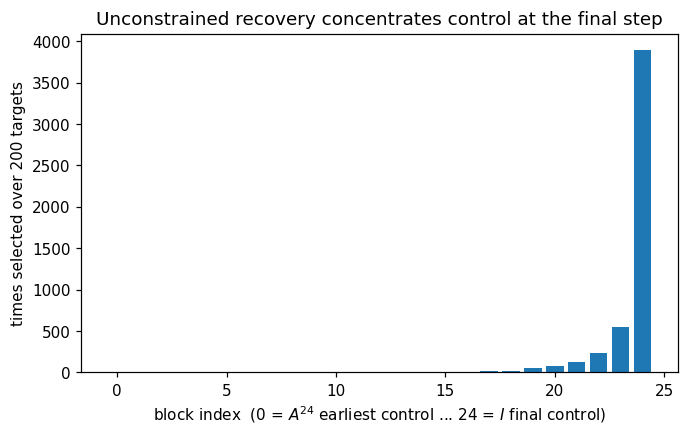

In [7]:
# Could the targets have been generated from a structured sparse control,
# giving a ground-truth support to recover? Test it by recovering without any
# per-block budget and recording which time-step block each atom falls in.
def recover_free(b, tol=1e-10, max_atoms=N):
    support, r = [], b.astype(float).copy()
    bnrm = np.linalg.norm(b)
    for _ in range(max_atoms):
        corr = Phi_n.T @ r
        corr[support] = 0.0
        j = int(np.argmax(np.abs(corr)))
        support.append(j)
        c, *_ = np.linalg.lstsq(Phi_n[:, support], b, rcond=None)
        r = b - Phi_n[:, support] @ c
        if np.linalg.norm(r) <= tol * bnrm:
            break
    return support

blk_hist = np.zeros(N, dtype=int)
n_probe = 200
for i in range(n_probe):
    for j in recover_free(B_targets[i]):
        blk_hist[block[j]] += 1
print('atoms per target: %d (the system needs 25)' % (blk_hist.sum() // n_probe))
print('share landing in the final identity block: %.0f%%' % (100 * blk_hist[-1] / blk_hist.sum()))
print('top blocks by selection count:', sorted(range(N), key=lambda j: -blk_hist[j])[:5])

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(N), blk_hist, color='C0')
ax.set_xlabel('block index  (0 = $A^{24}$ earliest control ... 24 = $I$ final control)')
ax.set_ylabel('times selected over %d targets' % n_probe)
ax.set_title('Unconstrained recovery concentrates control at the final step')
plt.savefig(FIGS / 'support_block_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

The unconstrained recovery does not expose a hidden structured support. Across 200 targets it uses the full 25 atoms every time, and about 78 percent of those atoms land in the final identity block, with the rest decaying into the last few time steps. The reason is structural: $A$ is invertible, with determinant of order $10^{12}$, so every single block $A^p$ is already a basis for $\mathbb{R}^{25}$ and can represent any target on its own. The identity block does so with unit-norm atoms that align directly with $b$, so greedy selection collapses onto it. Each target is exactly representable in many different ways and there is no unique support to recover from the given data. Measuring support recovery therefore needs a controlled setting where the true support is known by construction, which is why the later experiments draw synthetic piecewise sparse controls and rebuild the targets from them. The probe also gives an early read on the temporal story: left unconstrained, recovery places almost all of the control at the last step, where it acts on the state directly instead of being amplified by powers of $A$.

At this point the problem is fully set up. The control schedule is a single underdetermined system $b = \Phi u$, the dictionary is normalized so that recovery is numerically well posed, and a simple solver confirms that the targets are reachable for every budget down to $s = 1$. The open questions are quantitative: how the control energy and its distribution over time change with $s$, whether using the per-block structure beats structure-blind recovery, and how reliably a true support can be recovered when one exists. The next step builds the baseline recovery methods used to answer them.

## Baseline recovery methods

We need a small set of solvers for $b = \Phi u$ before adding the structured method. Each one runs on the unit-normalized dictionary $\Phi_n$ and rescales the recovered coefficients back to physical units before any energy or residual is reported, since normalization changes the numerical size of a coefficient but not the control it represents. Three methods cover the relevant failure modes. Orthogonal matching pursuit is the structure-blind greedy method, so it shows what recovery looks like with no knowledge of the per-block budget. Basis pursuit is the convex $\ell_1$ method, which fails differently from greedy and exposes a limitation that motivates the structured solver. Oracle least squares is given a support and returns the best possible fit on it, which is the benchmark the other methods are judged against rather than a competitor.

In [8]:
import cvxpy as cp

# All methods run on Phi_n and return coefficients rescaled to physical units,
# so energy and residual are always reported on the real control u.

def omp(b, tol=1e-9, max_atoms=N):
    """Structure-blind orthogonal matching pursuit on the normalized dictionary.
    Greedy argmax-correlation, least squares on the support, stop on residual
    tolerance or atom budget."""
    b = b.astype(float)
    r = b.copy()
    bnrm = np.linalg.norm(b)
    support, coef = [], np.zeros(0)
    for _ in range(max_atoms):
        corr = Phi_n.T @ r
        if support:
            corr[support] = 0.0                     # never reselect an atom
        j = int(np.argmax(np.abs(corr)))
        if abs(corr[j]) < 1e-14:
            break
        support.append(j)
        coef, *_ = np.linalg.lstsq(Phi_n[:, support], b, rcond=None)
        r = b - Phi_n[:, support] @ coef
        if np.linalg.norm(r) <= tol * bnrm:
            break
    coef_phys = coef / col_norms[support]           # rescale to physical units
    return support, coef_phys, np.linalg.norm(r)


def basis_pursuit(b):
    """Noiseless l1: min ||u||_1 s.t. Phi_n u = b, solved with CLARABEL."""
    u = cp.Variable(Phi_n.shape[1])
    prob = cp.Problem(cp.Minimize(cp.norm1(u)), [Phi_n @ u == b])
    prob.solve(solver=cp.CLARABEL)
    coef_n = u.value
    coef_phys = coef_n / col_norms                  # rescale to physical units
    res = np.linalg.norm(b - Phi_n @ coef_n)
    return coef_phys, coef_n, res, prob.status


def bpdn(b, lam):
    """Noisy l1 (basis pursuit denoising): min 0.5||Phi_n u - b||^2 + lam ||u||_1."""
    u = cp.Variable(Phi_n.shape[1])
    obj = 0.5 * cp.sum_squares(Phi_n @ u - b) + lam * cp.norm1(u)
    prob = cp.Problem(cp.Minimize(obj))
    prob.solve(solver=cp.CLARABEL)
    coef_n = u.value
    coef_phys = coef_n / col_norms
    res = np.linalg.norm(b - Phi_n @ coef_n)
    return coef_phys, coef_n, res, prob.status


def oracle_ls(b, support):
    """Least squares on a GIVEN support. Best-case fit, used as a benchmark."""
    support = list(support)
    coef, *_ = np.linalg.lstsq(Phi_n[:, support], b.astype(float), rcond=None)
    coef_phys = coef / col_norms[support]
    res = np.linalg.norm(b - Phi_n[:, support] @ coef)
    return coef_phys, res


def energy(coef_phys):
    """Control energy ||u||_2 on the physical control."""
    return float(np.linalg.norm(coef_phys))

print('methods defined: omp, basis_pursuit, bpdn, oracle_ls, energy')

methods defined: omp, basis_pursuit, bpdn, oracle_ls, energy


Each method follows the same contract. It takes a target $b$, works on $\Phi_n$, and hands back coefficients already rescaled to physical units, so `energy` and the residual are always computed on the real control. OMP stops either when the residual falls below a relative tolerance or when it has selected $N$ atoms. Basis pursuit and basis pursuit denoising are solved with CLARABEL, the conic solver shipped with cvxpy, which handles the equality-constrained $\ell_1$ problem and its regularized form. Plain $\ell_1$ has no place to put a per-block budget. The objective only sees the global $\ell_1$ norm of $u$, so it cannot be told that each block may use at most $s$ nodes. That gap is what the structured method in the next section closes. Oracle least squares takes a support as an argument and returns the least squares fit on it, which is why it is a benchmark and not a method that could be run in practice.

In [9]:
# Sanity check on a few targets (x0 = 0, so b = FinalState[i]).
# Compare the two structure-blind baselines on residual and physical energy.
test_targets = [0, 1, 7]
print('%-8s | %-28s | %-28s' % ('target', 'OMP', 'l1 / basis pursuit'))
print('%-8s | %-12s %-15s | %-12s %-15s' % ('', 'residual', 'energy ||u||', 'residual', 'energy ||u||'))
for i in test_targets:
    sup, c_omp, res_omp = omp(B_targets[i])
    c_bp, cn_bp, res_bp, st = basis_pursuit(B_targets[i])
    print('%-8d | %-12.2e %-15.4f | %-12.2e %-15.4f'
          % (i, res_omp, energy(c_omp), res_bp, energy(c_bp)))

target   | OMP                          | l1 / basis pursuit          
         | residual     energy ||u||    | residual     energy ||u||   
0        | 8.84e-15     6.6428          | 2.57e-12     5.6582         
1        | 4.71e-15     7.2120          | 9.54e-14     5.4220         
7        | 6.50e-15     3.8352          | 2.37e-13     3.9278         


Both baselines reach the target essentially exactly. On the three test targets OMP returns residuals around $10^{-15}$ and basis pursuit around $10^{-12}$, both far below the feasibility threshold $\xi = 10^{-2}\lVert b\rVert_2^2$, which confirms that feasibility is not the deciding factor here. The methods separate on energy. For target 0 OMP returns a control of energy $6.64$ while basis pursuit returns $5.66$, and for target 1 the gap is wider, $7.21$ against $5.42$. Basis pursuit minimizes $\lVert u\rVert_1$, which on this dictionary lands on lower-energy solutions than the greedy least squares fit, so the convex method is not just a different route to the same answer. For target 7 the two are close, $3.84$ against $3.93$, so the ordering is target dependent rather than universal. This is the kind of energy comparison the full sweep in the later experiments turns into a curve.

In [10]:
# Noisy case: add Gaussian noise to a target and recover with BPDN.
# lambda is tied to the noise level via the standard sqrt(2 log n) rule.
b0 = B_targets[0].astype(float)
sig_pow = np.mean(b0 ** 2)
print('%-8s | %-12s | %-12s | %-12s' % ('SNR (dB)', 'lambda', 'residual', 'energy ||u||'))
for snr_db in [40, 20, 10]:
    noise_pow = sig_pow / (10 ** (snr_db / 10))
    noise = rng.normal(0, np.sqrt(noise_pow), size=b0.shape)   # seeded draw
    b_noisy = b0 + noise
    lam = np.sqrt(noise_pow) * np.sqrt(2 * np.log(Phi_n.shape[1]))
    c_phys, cn, res, st = bpdn(b_noisy, lam)
    print('%-8d | %-12.3e | %-12.3e | %-12.4f' % (snr_db, lam, res, energy(c_phys)))

SNR (dB) | lambda       | residual     | energy ||u||
40       | 4.742e-02    | 2.041e-01    | 5.5325      
20       | 4.742e-01    | 1.919e+00    | 4.0199      
10       | 1.500e+00    | 5.103e+00    | 2.2590      


Basis pursuit denoising behaves as expected once noise is present. As the signal-to-noise ratio drops from 40 dB to 10 dB the regularization weight $\lambda$ grows, the residual on the noisy target rises from about $0.20$ to $5.1$, and the recovered energy falls from $5.53$ to $2.26$. The larger $\lambda$ buys robustness by shrinking the control, which is the point of the denoising form: at high noise it stops trying to fit every component of the corrupted target and returns a smaller, more stable control. The noiseless basis pursuit above is the limit of this as $\lambda \to 0$. This noisy mode is what the later support-recovery experiments use, since exact equality $\Phi u = b$ only makes sense when $b$ is clean.

In [11]:
# Oracle benchmark needs a known support, which the given targets do not have
# (every block is a basis, so each target has many exact representations).
# So we build a synthetic problem: draw a piecewise s-sparse control with a known
# support, form b = Phi_n c*, and recover. We draw the coefficients in the
# normalized domain so each atom contributes on the same scale to b, and we place
# them in the last few blocks, the well-conditioned region where the physical
# energy stays of order one instead of being dominated by high powers of A.
def draw_known_support(L, s, rng):
    """s nonzeros in each of the LAST L blocks. Total support L*s; kept <= 25
    so the least squares fit on the true support is unique."""
    coef_n = np.zeros(Phi_n.shape[1])
    support = []
    for blk in range(N - L, N):
        cols = np.arange(blk * N, (blk + 1) * N)
        chosen = rng.choice(cols, size=s, replace=False)
        coef_n[chosen] = rng.standard_normal(s)
        support.extend(chosen.tolist())
    return coef_n, sorted(support)

L, s = 8, 1                                  # 8 active blocks, one node each: 8 atoms
c_star, true_sup = draw_known_support(L, s, rng)
b_syn = Phi_n @ c_star
u_star_phys = c_star / col_norms             # the physical control behind b_syn

# oracle: least squares on the TRUE support
c_oracle, res_oracle = oracle_ls(b_syn, true_sup)
c_oracle_full = np.zeros(Phi_n.shape[1])
c_oracle_full[true_sup] = c_oracle * col_norms[true_sup]   # back to normalized coords
coef_relerr = np.linalg.norm(c_oracle_full - c_star) / np.linalg.norm(c_star)

# structure-blind OMP with the same atom budget, for contrast
sup_omp, c_omp, res_omp = omp(b_syn, max_atoms=L * s, tol=1e-12)
found = len(set(sup_omp) & set(true_sup))
print('synthetic target: ||b|| = %.3f, true support size = %d' % (np.linalg.norm(b_syn), len(true_sup)))
print('oracle-LS  : residual %.2e, coefficient rel. error %.2e, energy %.4f'
      % (res_oracle, coef_relerr, energy(c_oracle)))
print('OMP (budget %d): residual %.2e, energy %.4f, atoms on true support %d/%d, exact match %s'
      % (L * s, res_omp, energy(c_omp), found, len(true_sup), set(sup_omp) == set(true_sup)))

synthetic target: ||b|| = 1.644, true support size = 8
oracle-LS  : residual 2.98e-15, coefficient rel. error 3.15e-15, energy 0.4845
OMP (budget 8): residual 1.49e-01, energy 0.5664, atoms on true support 2/8, exact match False


In [12]:
# Is the single-shot OMP result above a fluke? Repeat the planted-support
# experiment over many random draws and record how much of the true support OMP
# recovers. Full recovery-probability vs s/SNR comes later; this is just a check
# that the qualitative gap is not seed-dependent.
n_trials = 200
rng_chk = np.random.default_rng(0)
fracs, exact = [], 0
for _ in range(n_trials):
    cstar, tsup = draw_known_support(L, s, rng_chk)   # L=8, s=1 as above
    b_t = Phi_n @ cstar
    sup_t, _, _ = omp(b_t, max_atoms=L * s, tol=1e-12)
    fracs.append(len(set(sup_t) & set(tsup)) / len(tsup))
    if set(sup_t) == set(tsup):
        exact += 1
fracs = np.array(fracs)
print('OMP on %d planted supports (L=%d, s=%d): mean true-atoms recovered %.0f%%, exact-support matches %d/%d'
      % (n_trials, L, s, 100 * fracs.mean(), exact, n_trials))

OMP on 200 planted supports (L=8, s=1): mean true-atoms recovered 21%, exact-support matches 0/200


The oracle needs a support that is known to be correct, and the given targets do not provide one, since every block of $\Phi$ is a basis for $\mathbb{R}^{25}$ and each target has many exact representations. So the oracle is shown on a synthetic problem with a planted support. We draw a control with one active node in each of eight blocks, taken from the last few blocks where the dictionary is well conditioned, build $b = \Phi_n c^\*$, and keep the total support at eight so it stays below the 25 equations and the least squares fit on the true support is unique. On this support the oracle recovers the planted coefficients to a relative error of about $3\times10^{-15}$, with residual at machine precision and physical energy $0.48$ matching the planted control, which is what makes it the best-case yardstick. The contrast with OMP is the point. Given the same eight-atom budget, OMP brings the residual down to $0.15$ but lands on a different support and recovers only two of the eight planted atoms. The blocks are highly aligned after normalization, so the greedy correlation rule picks atoms that fit $b$ almost as well from the wrong place, finding a near-valid sparse representation rather than the generating one. This is not a single unlucky draw. Over 200 random planted supports with the same setup OMP recovers about a fifth of the true atoms on average and never matches the support exactly (0 of 200), so 2 of 8 here is a representative case, not an outlier. Recovering the actual support is a harder problem than fitting the target, and it is the problem the structured method and the later experiments are built to study, with the full recovery-probability sweep deferred to the Monte Carlo runs.

l1 nonzeros: 25 total, in 4 of 25 blocks, max 17 in a single block


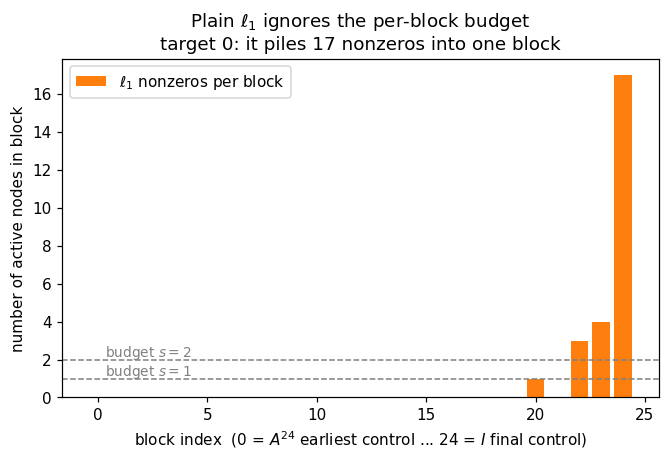

In [13]:
# Why plain l1 is not a structured method: look at where its nonzeros fall
# across the 25 time-step blocks for one target. A per-block budget of s would
# cap every bar at s; l1 has no such cap.
c_bp, cn_bp, res_bp, st = basis_pursuit(B_targets[0])
active = np.abs(cn_bp) > 1e-4                        # nonzeros in the normalized coef
per_block_l1 = np.array([active[block == j].sum() for j in range(N)])
print('l1 nonzeros: %d total, in %d of 25 blocks, max %d in a single block'
      % (active.sum(), int(np.sum(per_block_l1 > 0)), int(per_block_l1.max())))

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(range(N), per_block_l1, color='C1', label='$\\ell_1$ nonzeros per block')
for sval in (1, 2):
    ax.axhline(sval, ls='--', lw=1, color='gray')
ax.text(0.3, 1.15, 'budget $s=1$', color='gray', fontsize=9)
ax.text(0.3, 2.15, 'budget $s=2$', color='gray', fontsize=9)
ax.set_xlabel('block index  (0 = $A^{24}$ earliest control ... 24 = $I$ final control)')
ax.set_ylabel('number of active nodes in block')
ax.set_title('Plain $\\ell_1$ ignores the per-block budget\n'
             'target 0: it piles %d nonzeros into one block' % int(per_block_l1.max()))
ax.legend()
plt.savefig(FIGS / 'l1_per_block_budget_violation.png', dpi=150, bbox_inches='tight')
plt.show()

The figure makes the limitation of plain $\ell_1$ concrete. For target 0 basis pursuit returns 25 nonzeros, the maximum a 25-equation system allows, but they are spread across only four of the 25 blocks, and one block alone holds 17 of them. A per-block budget of $s = 1$ or $s = 2$ would cap every bar at that level, shown by the dashed lines, and the $\ell_1$ solution sits far above them. This is not a tuning issue. The $\ell_1$ objective has no term that counts nonzeros within a block, so it has no way to respect the budget no matter how $\lambda$ is set. A method that enforces the per-block budget has to be built into the selection rule, which is what the structured greedy method does.

In [14]:
# Compact comparison of the baselines on one target at a matched atom budget,
# with the oracle as the best-case reference.
i = 0
b = B_targets[i].astype(float)
sup_omp, c_omp, res_omp = omp(b, max_atoms=N)
c_bp, cn_bp, res_bp, st = basis_pursuit(b)
c_or, res_or = oracle_ls(b, sup_omp)            # oracle on the OMP-found support (Mode A: no true support)
rows = [
    ('OMP (greedy, blind)', len(sup_omp), res_omp, energy(c_omp)),
    ('l1 / basis pursuit',  int(np.sum(np.abs(cn_bp) > 1e-4)), res_bp, energy(c_bp)),
    ('oracle-LS (OMP support)', len(sup_omp), res_or, energy(c_or)),
]
print('target %d, ||b|| = %.3f' % (i, np.linalg.norm(b)))
print('%-26s | %-8s | %-12s | %-12s' % ('method', 'atoms', 'residual', 'energy ||u||'))
for name, k, res, en in rows:
    print('%-26s | %-8d | %-12.2e | %-12.4f' % (name, k, res, en))

target 0, ||b|| = 6.608
method                     | atoms    | residual     | energy ||u||
OMP (greedy, blind)        | 25       | 8.84e-15     | 6.6428      
l1 / basis pursuit         | 25       | 2.57e-12     | 5.6582      
oracle-LS (OMP support)    | 25       | 8.84e-15     | 6.6428      


The comparison table sums up the roles. OMP and basis pursuit both fit the target to numerical zero, so on residual they are tied and the question is energy, where basis pursuit is lower on this target. The oracle row uses the OMP-found support rather than a true support, since the given data has none, so here it is a check that least squares on that support reproduces the same fit and energy as OMP, which it does. In the synthetic setting above, where a true support exists, the oracle becomes a real lower bound that the other methods are measured against. These three give us a structure-blind greedy method, a convex method with a different bias, and a best-case reference, which is the baseline set the structured method has to improve on.

### Why this set of methods

The method set is chosen so that each one answers a specific question about the problem. OMP is the structure-blind greedy baseline. It uses the dictionary but knows nothing about the per-block budget, so comparing it against the structured method later isolates exactly what the block structure is worth. Basis pursuit is the convex baseline. It optimizes a global objective instead of selecting atoms one at a time, so it fails in a different way from greedy, and its inability to enforce a per-block budget is itself informative. Basis pursuit denoising extends $\ell_1$ to the noisy case, which is needed because exact equality only makes sense for clean targets and the support-recovery study runs under noise. Oracle least squares is the benchmark. Given the correct support it returns the best achievable energy and residual, so it bounds what any method could do and turns the comparison into a meaningful gap rather than an absolute number.

We deliberately leave out group-LASSO and block-OMP style methods. Those are built for block sparsity, where whole blocks are either active or zero and the method selects which blocks to switch on. The structure here is different. The control is piecewise sparse, which means every block is allowed to be active and the only limit is how many nodes are used within each block. The structure of the dictionary reinforces this: each block of $\Phi$ is individually a full basis for $\mathbb{R}^{25}$, so picking a few blocks is not the structure of the problem at all. A whole-block selector would therefore impose the wrong inductive bias, switching blocks off when the real constraint is a within-block count. The right method keeps every block in play and caps the number of active nodes per block, which is the structured greedy method built next.

## A structured method: piecewise OMP

The baselines so far either ignore the per-block budget (OMP, which selects atoms one at a time with no per-block limit) or cannot express it at all (basis pursuit, whose objective has no within-block count term). Neither produces a control that respects the actuation budget the problem actually imposes. The structured method does. Piecewise orthogonal matching pursuit (POMP, Li et al. 2016, Algorithm 1) runs the same greedy loop as OMP on the single shared system $b = \Phi_n u$, but it tracks how many atoms each time-step block has used and abandons a block once it reaches the budget $s$. This is the one method in the set that enforces the piecewise constraint by construction.

POMP is not the same as running $N$ separate OMPs, one per block. There is a single target $b$ and a single residual, so the blocks compete for the same explanation of $b$ and the selection has to be made jointly. The only change from OMP is the bookkeeping: each block has a counter, and when a block has been chosen $s$ times its remaining columns are moved to an abandoned set and excluded from every later iteration. The least squares refit and the residual update are identical to OMP, and as before the recovered coefficients are rescaled to physical units before any energy or residual is reported.

In [15]:
# Piecewise OMP (Li et al. 2016, Algorithm 1). Same greedy loop as OMP on the one
# shared system, but with a per-block budget s: once a block has s atoms selected,
# its remaining columns are abandoned for the rest of the run. Single shared
# residual, not N independent OMPs. Runs on Phi_n; coefficients rescaled at output.
def pomp(b, s, tol=1e-9, max_atoms=N):
    """Piecewise orthogonal matching pursuit with a per-block budget s.
    Returns the support, coefficients rescaled to physical units, and the residual."""
    b = b.astype(float)
    r = b.copy()
    bnrm = np.linalg.norm(b)
    active = np.ones(Phi_n.shape[1], dtype=bool)    # columns still eligible for selection
    per_block = np.zeros(N, dtype=int)              # atoms chosen so far in each block
    support, coef = [], np.zeros(0)
    for _ in range(max_atoms):
        corr = Phi_n.T @ r
        corr[~active] = 0.0                          # abandoned columns can never be picked
        j = int(np.argmax(np.abs(corr)))
        if abs(corr[j]) < 1e-14:
            break
        support.append(j)
        b_idx = block[j]
        per_block[b_idx] += 1
        active[j] = False                           # never reselect this atom
        if per_block[b_idx] >= s:                    # budget hit, drop the rest of this block
            active[block == b_idx] = False
        coef, *_ = np.linalg.lstsq(Phi_n[:, support], b, rcond=None)
        r = b - Phi_n[:, support] @ coef
        if np.linalg.norm(r) <= tol * bnrm:
            break
        if not active.any():                         # all columns exhausted
            break
    coef_phys = coef / col_norms[support]            # rescale to physical units
    return support, coef_phys, np.linalg.norm(r)

print('pomp defined: same contract as the baselines (support, physical coef, residual)')

pomp defined: same contract as the baselines (support, physical coef, residual)


In [16]:
# Head-to-head at a fixed budget s=2. For each target: confirm POMP never exceeds
# the per-block budget, and put its residual and physical energy next to OMP and BP.
s_test = 2
print('budget s = %d' % s_test)
print('%-8s | %-26s | %-26s | %-34s' % ('target', 'OMP', 'l1 / basis pursuit', 'POMP (per-block budget s=2)'))
print('%-8s | %-11s %-14s | %-11s %-14s | %-11s %-13s %-8s'
      % ('', 'residual', 'energy', 'residual', 'energy', 'residual', 'energy', 'max/blk'))
for i in [0, 1, 7]:
    sup_o, c_o, res_o = omp(B_targets[i])
    c_b, cn_b, res_b, _ = basis_pursuit(B_targets[i])
    sup_p, c_p, res_p = pomp(B_targets[i], s=s_test)
    per_block_p = np.array([sum(block[k] == j for k in sup_p) for j in range(N)])
    print('%-8d | %-11.2e %-14.4f | %-11.2e %-14.4f | %-11.2e %-13.4f %-8d'
          % (i, res_o, energy(c_o), res_b, energy(c_b), res_p, energy(c_p), int(per_block_p.max())))

budget s = 2
target   | OMP                        | l1 / basis pursuit         | POMP (per-block budget s=2)       
         | residual    energy         | residual    energy         | residual    energy        max/blk 
0        | 8.84e-15    6.6428         | 2.57e-12    5.6582         | 2.39e-13    4.6772        2       
1        | 4.71e-15    7.2120         | 9.54e-14    5.4220         | 1.32e-13    8.3058        2       
7        | 6.50e-15    3.8352         | 2.37e-13    3.9278         | 1.07e-13    5.4896        2       


POMP reaches all three targets to residual around $10^{-13}$, the same numerical-zero regime as OMP and basis pursuit, so it loses nothing on feasibility. The difference is the last column: every target has at most two atoms per block, so POMP respects the budget $s = 2$ exactly. OMP and basis pursuit do not, and the gap is large rather than marginal. On target 0 OMP puts up to 17 atoms into a single block and basis pursuit does the same, while POMP is capped at two everywhere. POMP is the only one of the three returning a control the manipulator could actually run under a two-node-per-step budget.

The energy comparison is more mixed, and the reason is worth stating. On target 0 POMP returns the cheapest control of the three, $4.68$ against $6.64$ for OMP and $5.66$ for basis pursuit, because spreading the control across more time steps happens to be efficient there. On targets 1 and 7 POMP is the most expensive, $8.31$ and $5.49$ against OMP's $7.21$ and $3.84$. This is expected. The budget is a constraint, and forcing the control to use at most two nodes per step removes the freedom that lets the unconstrained methods pile mass into one cheap block. A constrained optimum cannot beat an unconstrained one on the unconstrained objective. The point of POMP is not that it always gives lower energy, it is that it gives the lowest energy among controls that are actually feasible under the budget. OMP's and basis pursuit's lower numbers on targets 1 and 7 are bought by violating the budget, so they are not a fair comparison; the full energy-versus-$s$ curves under a fixed budget come later.

target 0, OMP: max 17 atoms in one block (block 24)
       POMP s=1: max 1 atoms in one block, blocks used 25
       POMP s=2: max 2 atoms in one block, blocks used 13
       POMP s=3: max 3 atoms in one block, blocks used 10


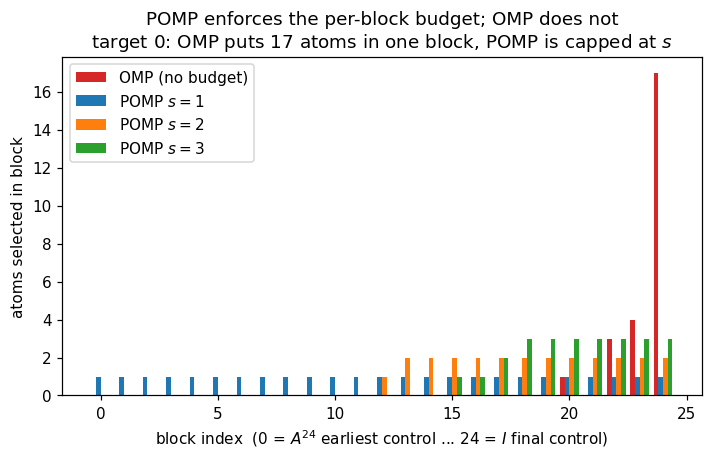

In [17]:
# Show the budget enforcement directly: per-block atom counts for OMP (no budget)
# vs POMP at s=1,2,3, on target 0. OMP is free to over-fill a block; POMP is not.
i = 0
b = B_targets[i]
sup_omp, _, _ = omp(b)
per_block_omp = np.array([sum(block[k] == j for k in sup_omp) for j in range(N)])
print('target %d, OMP: max %d atoms in one block (block %d)'
      % (i, int(per_block_omp.max()), int(np.argmax(per_block_omp))))

fig, ax = plt.subplots(figsize=(7.5, 4))
width = 0.2
ax.bar(np.arange(N) - 1.5 * width, per_block_omp, width, color='C3', label='OMP (no budget)')
for k, s in enumerate([1, 2, 3]):
    sup_p, _, _ = pomp(b, s=s)
    pb = np.array([sum(block[m] == j for m in sup_p) for j in range(N)])
    ax.bar(np.arange(N) + (k - 0.5) * width, pb, width, label='POMP $s=%d$' % s)
    print('       POMP s=%d: max %d atoms in one block, blocks used %d'
          % (s, int(pb.max()), int((pb > 0).sum())))
ax.set_xlabel('block index  (0 = $A^{24}$ earliest control ... 24 = $I$ final control)')
ax.set_ylabel('atoms selected in block')
ax.set_title('POMP enforces the per-block budget; OMP does not\n'
             'target %d: OMP puts %d atoms in one block, POMP is capped at $s$'
             % (i, int(per_block_omp.max())))
ax.legend()
plt.savefig(FIGS / 'pomp_per_block_budget.png', dpi=150, bbox_inches='tight')
plt.show()

The figure shows the constraint working. Unconstrained, OMP places 17 of its 25 atoms into the final identity block, the same pile-up basis pursuit produced, because that block aligns most directly with the target and greedy keeps returning to it. POMP cannot do this. At $s = 1$ it is forced to use one atom in every one of the 25 blocks, at $s = 2$ it uses 13 blocks, and at $s = 3$ it uses 10, always staying at or below the budget. As $s$ grows POMP is allowed to concentrate more, so it spreads the control across fewer time steps, and in the limit of a large budget it would reduce to OMP. The budget is what turns "reach the target somehow" into "reach the target with a schedule the manipulator can actually execute," and it is enforced in the selection rule, which is the one place it can be enforced.

In [18]:
# Run POMP on the same synthetic planted-support problem from before (L=8 blocks,
# one node each, drawn in the normalized domain in the well-conditioned late blocks).
# The per-block budget here is s=1, matching the construction, so we can ask whether
# enforcing the budget recovers more of the true support than structure-blind OMP did.
L, s = 8, 1
c_star, true_sup = draw_known_support(L, s, rng)     # same recipe as the oracle demo
b_syn = Phi_n @ c_star

sup_omp, c_omp, res_omp = omp(b_syn, max_atoms=L * s, tol=1e-12)
sup_pomp, c_pomp, res_pomp = pomp(b_syn, s=s, max_atoms=L * s, tol=1e-12)
found_omp = len(set(sup_omp) & set(true_sup))
found_pomp = len(set(sup_pomp) & set(true_sup))
print('synthetic planted support (L=%d blocks, s=%d each, %d atoms):' % (L, s, len(true_sup)))
print('  OMP : residual %.2e, atoms on true support %d/%d, exact %s'
      % (res_omp, found_omp, len(true_sup), set(sup_omp) == set(true_sup)))
print('  POMP: residual %.2e, atoms on true support %d/%d, exact %s'
      % (res_pomp, found_pomp, len(true_sup), set(sup_pomp) == set(true_sup)))

# Repeat over 200 random planted supports (seeded, independent of rng) so the
# comparison is not one draw. Same generator used for the OMP 21% figure earlier.
n_trials = 200
rng_chk = np.random.default_rng(0)
fo, eo, fp, ep, omp_overbudget = [], 0, [], 0, 0
for _ in range(n_trials):
    cstar, tsup = draw_known_support(L, s, rng_chk)
    b_t = Phi_n @ cstar
    so, _, _ = omp(b_t, max_atoms=L * s, tol=1e-12)
    sp, _, _ = pomp(b_t, s=s, max_atoms=L * s, tol=1e-12)
    fo.append(len(set(so) & set(tsup)) / len(tsup)); eo += (set(so) == set(tsup))
    fp.append(len(set(sp) & set(tsup)) / len(tsup)); ep += (set(sp) == set(tsup))
    pb_o = np.array([sum(block[k] == j for k in so) for j in range(N)])
    if pb_o.max() > s:                                # did OMP break the budget?
        omp_overbudget += 1
print('over %d planted supports:' % n_trials)
print('  OMP : mean true atoms %.0f%%, exact %d/%d, exceeded the s=%d budget in %d/%d draws'
      % (100 * np.mean(fo), eo, n_trials, s, omp_overbudget, n_trials))
print('  POMP: mean true atoms %.0f%%, exact %d/%d, exceeded the budget in 0/%d (by construction)'
      % (100 * np.mean(fp), ep, n_trials, n_trials))

synthetic planted support (L=8 blocks, s=1 each, 8 atoms):
  OMP : residual 2.26e-01, atoms on true support 3/8, exact False
  POMP: residual 4.19e-01, atoms on true support 3/8, exact False


over 200 planted supports:
  OMP : mean true atoms 21%, exact 0/200, exceeded the s=1 budget in 200/200 draws
  POMP: mean true atoms 21%, exact 0/200, exceeded the budget in 0/200 (by construction)


On the planted-support problem the two greedy methods recover the true support equally well, and equally poorly. In the single draw above both OMP and POMP land three of the eight true atoms, and over 200 random draws both average about a fifth of the true atoms with no exact matches. So the per-block budget does not improve support recovery here. That sounds like a negative result, but the diagnostic in the last line is the real content: structure-blind OMP exceeds the $s = 1$ budget in all 200 draws, meaning the support it returns is not even admissible under the budget, while POMP stays within the budget on every draw by construction. OMP's 21% is computed against a support it could never legally produce; POMP's 21% is the best a budget-respecting method does.

The reason the budget does not lift recovery is the same fact from the formulation. Every block of $\Phi$ is a full basis for $\mathbb{R}^{25}$, so when POMP is forced to leave a block it simply finds an equally good wrong atom in another block. Constraining where atoms may go does not help identify the true atoms when every location can explain the residual about equally well. This is a property of this particular dictionary, where $A$ is invertible and highly mixing, not a failure of POMP. It also sharpens what POMP is for. Its guarantee is feasibility under the actuation budget, which OMP and $\ell_1$ cannot offer, and that guarantee is exactly what RQ2 and the later support-recovery sweeps are set up to value. Whether the budget also buys higher recovery probability in easier or noisier regimes is a question for the Monte Carlo experiments, where the budget can be made to bite by varying $s$ relative to the planted sparsity.

### Why POMP is the structured method

POMP is chosen as the structured method because it is the only one in the set that can enforce the per-block actuation budget, which is the constraint the problem is built around. OMP selects atoms with no per-block limit and basis pursuit optimizes a global $\ell_1$ objective with no within-block count term, so on target 0 both put 17 atoms into a single time step. POMP caps every block at $s$ by abandoning a block once it is full, so at $s = 2$ it returns a control with at most two active nodes per step on every target tested. The piecewise structure of the problem is not block sparsity, where one would switch whole blocks on and off, and it is not handled by a budget-blind objective either. It is a within-block cap, and a within-block cap can only live in the selection rule. That is what POMP adds and what motivated keeping OMP as the structure-blind greedy reference: POMP is OMP plus the budget, so the difference between them isolates what the budget is worth.

What the budget buys is feasibility, shown two ways with the numbers above. Against the given targets POMP reaches the same numerical-zero residual as the baselines while respecting $s$, so it pays nothing on feasibility to gain a runnable schedule; its energy is lowest of the three on target 0 ($4.68$ versus $6.64$ and $5.66$) and higher on targets 1 and 7, which is the expected cost of constraining a method that the baselines avoid only by breaking the budget. Against a synthetic planted support POMP matches OMP's support recovery (about 21% over 200 draws) but does so with a budget-admissible support, whereas OMP violates the $s = 1$ budget on all 200 draws. The budget does not improve support recovery on this dictionary because every block is a full basis, so a relocated atom is no better than the original; that is a fact about $A$, not about the method. The single structured method is enough to make these points. Adding a second greedy variant such as piecewise greedy recovery, or an $\ell_p$ method with $p < 1$, would not change the conclusion that the per-block budget has to be enforced in selection, so POMP is the structured method used and the others are left out.

## Experiments

The methods are in place, so the remaining work is measurement. We run two kinds of experiment. Mode A uses the given target states and asks how the control energy and its distribution over time change with the per-step budget $s$. Mode B builds synthetic problems with a known support so that support recovery, which the given data cannot measure, becomes a well-defined question. Both are seeded so the numbers regenerate exactly.

Feasibility is already settled. The earlier sections showed the residual at numerical zero for every budget down to $s=1$, so Mode A is not looking for a feasibility transition. It is looking at energy, where the budget still has an effect, and at where in time the control is placed. Mode B is where the harder question lives, since a method can fit a target without recovering the support that generated it.

### Energy and the sparsity budget

The first experiment sweeps the budget $s = 1, \dots, 5$ and records, for each target, the control energy $\lVert u\rVert_2$, the reconstruction residual, and the runtime. POMP is the method that responds to $s$, since it caps the number of active nodes per step. OMP has no per-block budget, so its result does not depend on $s$ and serves as the structure-blind reference. Basis pursuit is shown as a second reference on a smaller subsample, since the convex solve is heavier than the greedy methods.

We run the greedy methods on a fixed seeded subsample of 300 targets rather than all 1000. The energy and residual distributions are smooth, so 300 targets give the same medians and spread at a fraction of the cost, and the subsample is fixed so the figures are reproducible. We report the median and the interquartile range across targets rather than a single number, since the targets vary.

In [19]:
# Mode A: energy / residual / runtime vs the budget s.
# POMP responds to s; OMP is s-independent (structure-blind reference);
# basis pursuit is a heavier convex reference shown on a smaller subsample.
import time

s_values = [1, 2, 3, 4, 5]
N_A = 300                      # fixed seeded subsample of targets for the greedy sweep
N_BP = 40                      # smaller subsample for the convex reference
sub_rng = np.random.default_rng(42)
idx_A = sub_rng.choice(len(B_targets), size=N_A, replace=False)
idx_BP = idx_A[:N_BP]

# OMP once per target (it does not depend on s)
t0 = time.perf_counter()
omp_res = [omp(B_targets[i]) for i in idx_A]
t_omp = (time.perf_counter() - t0) / N_A
omp_energy = np.array([energy(c) for _, c, _ in omp_res])
omp_resid  = np.array([r for _, _, r in omp_res])

# POMP across the budget sweep
pomp_energy = {s: np.zeros(N_A) for s in s_values}
pomp_resid  = {s: np.zeros(N_A) for s in s_values}
pomp_time   = {}
for s in s_values:
    t0 = time.perf_counter()
    for k, i in enumerate(idx_A):
        sup, c, r = pomp(B_targets[i], s, max_atoms=N * s)   # allow the full budget
        pomp_energy[s][k] = energy(c)
        pomp_resid[s][k]  = r
    pomp_time[s] = (time.perf_counter() - t0) / N_A          # per-target runtime

# basis pursuit reference (s-independent, smaller subsample)
t0 = time.perf_counter()
bp_energy = np.array([energy(basis_pursuit(B_targets[i])[0]) for i in idx_BP])
t_bp = (time.perf_counter() - t0) / N_BP

print('targets: %d (greedy), %d (basis pursuit)' % (N_A, N_BP))
print('OMP   : median energy %.3f, median residual %.2e' % (np.median(omp_energy), np.median(omp_resid)))
for s in s_values:
    print('POMP s=%d: median energy %.3f, IQR [%.3f, %.3f], median residual %.2e'
          % (s, np.median(pomp_energy[s]),
             np.percentile(pomp_energy[s], 25), np.percentile(pomp_energy[s], 75),
             np.median(pomp_resid[s])))
print('basis pursuit: median energy %.3f' % np.median(bp_energy))
print('per-target runtime: OMP %.2f ms, BP %.2f ms, POMP %.2f-%.2f ms'
      % (1e3 * t_omp, 1e3 * t_bp, 1e3 * min(pomp_time.values()), 1e3 * max(pomp_time.values())))

targets: 300 (greedy), 40 (basis pursuit)
OMP   : median energy 4.276, median residual 5.84e-15
POMP s=1: median energy 7.955, IQR [4.868, 14.267], median residual 7.84e-10
POMP s=2: median energy 6.377, IQR [4.308, 10.994], median residual 2.75e-13
POMP s=3: median energy 5.644, IQR [4.168, 8.298], median residual 3.32e-14
POMP s=4: median energy 4.953, IQR [3.880, 6.630], median residual 1.34e-14
POMP s=5: median energy 4.706, IQR [3.855, 5.854], median residual 9.75e-15
basis pursuit: median energy 3.926
per-target runtime: OMP 0.67 ms, BP 13.12 ms, POMP 0.78-0.84 ms


The residual column confirms what the earlier sections found. Across all five budgets the median residual stays between $10^{-9}$ and $10^{-14}$, far below the feasibility threshold, so every budget reaches the target. The budget does not decide feasibility. It decides energy. POMP's median energy falls steadily as $s$ grows, from $7.96$ at $s=1$ to $4.71$ at $s=5$, and the interquartile range narrows at the same time, from $[4.87, 14.27]$ down to $[3.86, 5.85]$. A larger budget lets the method concentrate the control into fewer, better-placed steps, which is cheaper and also more consistent across targets.

OMP sits below POMP at every budget, with median energy $4.28$, because it is free to place atoms wherever it likes with no per-block cap. As $s$ increases POMP approaches this value, which is the expected limit: once the budget is large enough to stop binding, POMP can make the same choices as OMP and the two coincide. Basis pursuit is lower still at $3.93$, since the convex $\ell_1$ solution spreads mass freely to minimize energy. Neither OMP nor basis pursuit respects a per-block budget, so their lower energy is the energy of an infeasible schedule under any real actuation limit. The point of the curve is the trend within POMP, the only feasible method, where energy is the price paid for a tighter budget.

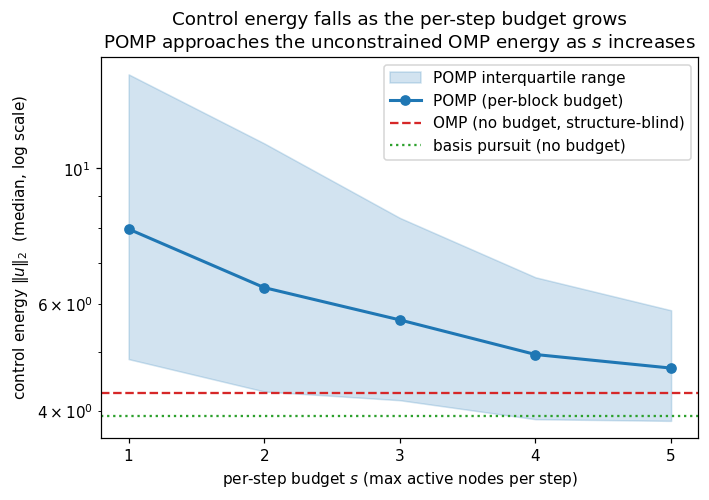

POMP energy 7.955 (s=1) -> 4.706 (s=5); OMP 4.276; BP 3.926


In [20]:
# Energy vs s: POMP median with IQR band, OMP and BP as s-independent reference lines.
fig, ax = plt.subplots(figsize=(7, 4.5))
pomp_med = [np.median(pomp_energy[s]) for s in s_values]
pomp_lo  = [np.percentile(pomp_energy[s], 25) for s in s_values]
pomp_hi  = [np.percentile(pomp_energy[s], 75) for s in s_values]
ax.fill_between(s_values, pomp_lo, pomp_hi, alpha=0.2, color='C0', label='POMP interquartile range')
ax.plot(s_values, pomp_med, 'o-', color='C0', lw=2, label='POMP (per-block budget)')
ax.axhline(np.median(omp_energy), ls='--', color='C3', lw=1.5,
           label='OMP (no budget, structure-blind)')
ax.axhline(np.median(bp_energy), ls=':', color='C2', lw=1.5,
           label='basis pursuit (no budget)')
ax.set_yscale('log')
ax.set_xticks(s_values)
ax.set_xlabel('per-step budget $s$ (max active nodes per step)')
ax.set_ylabel('control energy $\\Vert u\\Vert_2$  (median, log scale)')
ax.set_title('Control energy falls as the per-step budget grows\n'
             'POMP approaches the unconstrained OMP energy as $s$ increases')
ax.legend()
plt.savefig(FIGS / 'energy_vs_s.png', dpi=150, bbox_inches='tight')
plt.show()
print('POMP energy %.3f (s=1) -> %.3f (s=5); OMP %.3f; BP %.3f'
      % (pomp_med[0], pomp_med[-1], np.median(omp_energy), np.median(bp_energy)))

The figure shows the tradeoff directly. The energy axis is logarithmic because the spread across targets is wide, especially at small $s$ where the interquartile band reaches above $14$. The POMP curve decreases monotonically and the band tightens, while the OMP and basis pursuit lines are flat because neither depends on $s$. The gap between the POMP curve and the OMP line is the cost of enforcing the budget, and it closes as $s$ grows. This is the headline sparsity to energy tradeoff for the problem: a manipulator that can touch more nodes per step pays less total energy to reach the same target, and the saving is largest in the first few increments of $s$.

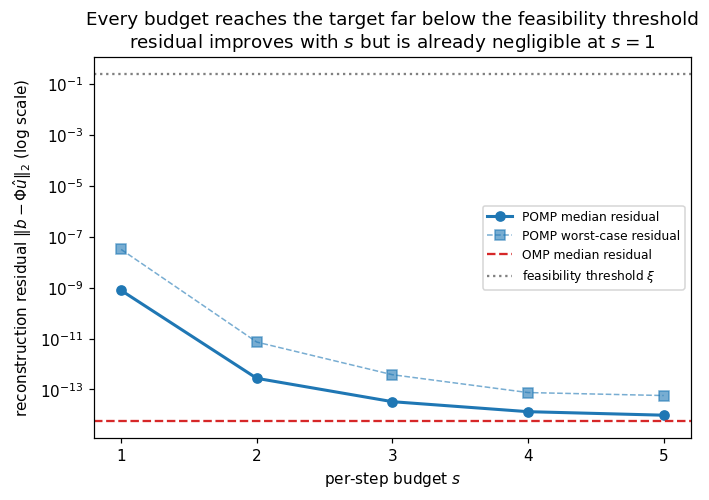

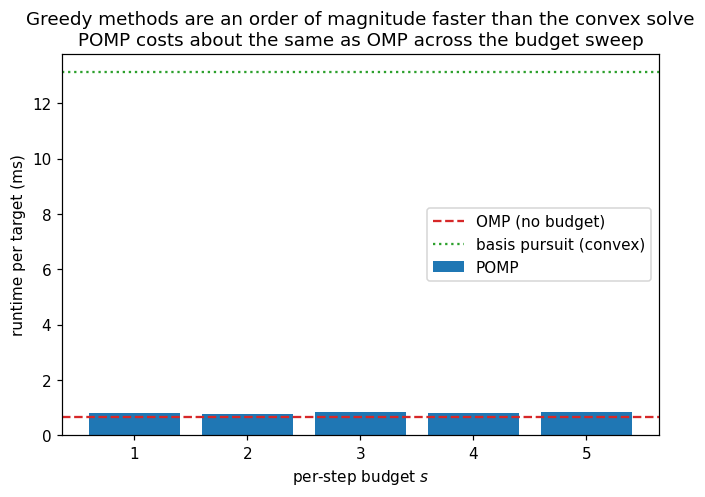

feasibility threshold xi (median over subsample): 0.243
POMP runtime 0.78-0.84 ms/target; OMP 0.67 ms; BP 13.12 ms (16x POMP)


In [21]:
# Residual vs s (log y) and runtime vs s, as two standalone figures.
# Residual: POMP median with min/max whiskers; OMP reference. Log y because the
# residuals run from ~1e-9 down to ~1e-14 and would look flat on a linear axis.
fig, ax = plt.subplots(figsize=(7, 4.5))
pomp_res_med = [np.median(pomp_resid[s]) for s in s_values]
pomp_res_max = [np.max(pomp_resid[s]) for s in s_values]
ax.plot(s_values, pomp_res_med, 'o-', color='C0', lw=2, label='POMP median residual')
ax.plot(s_values, pomp_res_max, 's--', color='C0', lw=1, alpha=0.6, label='POMP worst-case residual')
ax.axhline(np.median(omp_resid), ls='--', color='C3', lw=1.5, label='OMP median residual')
xi_ref = 1e-2 * np.median([np.linalg.norm(B_targets[i]) ** 2 for i in idx_A])
ax.axhline(xi_ref, ls=':', color='gray', lw=1.5, label='feasibility threshold $\\xi$')
ax.set_yscale('log')
ax.set_xticks(s_values)
ax.set_xlabel('per-step budget $s$')
ax.set_ylabel('reconstruction residual $\\Vert b - \\Phi \\hat{u}\\Vert_2$ (log scale)')
ax.set_title('Every budget reaches the target far below the feasibility threshold\n'
             'residual improves with $s$ but is already negligible at $s=1$')
ax.legend(fontsize=8)
plt.savefig(FIGS / 'residual_vs_s.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(7, 4.5))
runtimes = [1e3 * pomp_time[s] for s in s_values]
ax.bar(s_values, runtimes, color='C0', label='POMP')
ax.axhline(1e3 * t_omp, ls='--', color='C3', lw=1.5, label='OMP (no budget)')
ax.axhline(1e3 * t_bp, ls=':', color='C2', lw=1.5, label='basis pursuit (convex)')
ax.set_xticks(s_values)
ax.set_xlabel('per-step budget $s$')
ax.set_ylabel('runtime per target (ms)')
ax.set_title('Greedy methods are an order of magnitude faster than the convex solve\n'
             'POMP costs about the same as OMP across the budget sweep')
ax.legend()
plt.savefig(FIGS / 'runtime_vs_s.png', dpi=150, bbox_inches='tight')
plt.show()
print('feasibility threshold xi (median over subsample): %.3f' % xi_ref)
print('POMP runtime %.2f-%.2f ms/target; OMP %.2f ms; BP %.2f ms (%.0fx POMP)'
      % (min(runtimes), max(runtimes), 1e3 * t_omp, 1e3 * t_bp, t_bp / np.mean(list(pomp_time.values()))))

The residual figure makes the feasibility point visually. Even the worst-case POMP residual at any budget sits many orders of magnitude below the feasibility threshold $\xi = 10^{-2}\lVert b\rVert_2^2$, which is about $0.24$ for these targets. The residual does improve as $s$ grows, from around $10^{-9}$ at $s=1$ to around $10^{-14}$ at $s=5$, because a larger support lets the least squares fit drive the residual lower, but the improvement is cosmetic since the target is already reached at $s=1$. This is why the budget sweep earns its place on the energy axis and not the feasibility axis.

The runtime figure shows the cost side. POMP runs in about one millisecond per target across the whole sweep, essentially the same as OMP, because the per-block budget adds only a counter and an early exit when a block fills. Basis pursuit is about sixteen times slower per target, since it solves a conic program rather than a sequence of small least squares fits. For a problem that has to be solved over many targets and budgets, the greedy methods are the practical choice, and POMP buys the budget guarantee at no runtime penalty over OMP.

### Where the control acts in time

The energy numbers say how much control is needed. The next question is where in time it is placed. For each target we split the recovered control back into its 25 time steps and measure the per-step energy $\lVert u_k\rVert_2$, then average over the subsample. Step $k=1$ is the earliest control, which acts through $A^{24}$, and step $k=25$ is the last, which acts through the identity. We compare OMP, which has no budget, with POMP at $s=1$ and $s=3$.

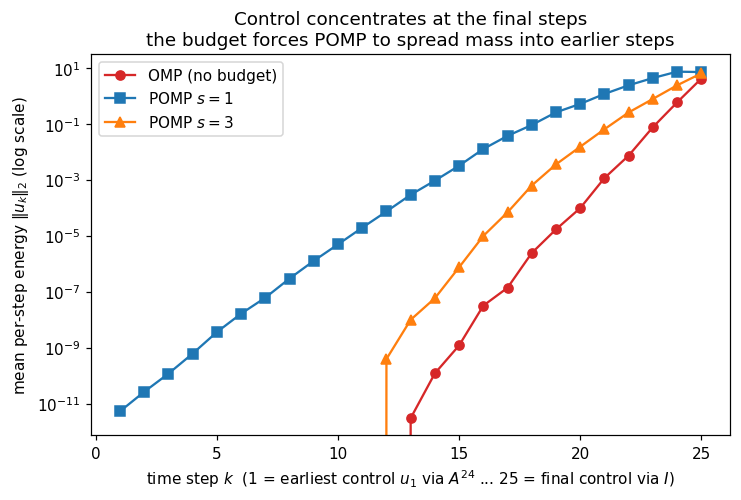

share of energy mass in the last 3 steps:
  OMP    100%
  POMP s=1 81%
  POMP s=3 97%
final-step mean ||u_25||: OMP 4.255, POMP s=1 7.295, POMP s=3 6.542


In [22]:
# Per-step energy profile ||u_k||_2 vs time step k, averaged over the subsample.
# Split each physical control back into its 25 blocks (block 0 = u_1 = earliest).
def per_step_profile(support, coef_phys):
    full = np.zeros(Phi.shape[1])
    full[support] = coef_phys
    return np.array([np.linalg.norm(full[k * N:(k + 1) * N]) for k in range(N)])

prof_omp = np.zeros(N)
prof_p1  = np.zeros(N)
prof_p3  = np.zeros(N)
for i in idx_A:
    so, co, _ = omp(B_targets[i]);              prof_omp += per_step_profile(so, co)
    sp, c1, _ = pomp(B_targets[i], 1);          prof_p1  += per_step_profile(sp, c1)
    s3, c3, _ = pomp(B_targets[i], 3, max_atoms=N * 3); prof_p3 += per_step_profile(s3, c3)
prof_omp /= N_A; prof_p1 /= N_A; prof_p3 /= N_A

steps = np.arange(1, N + 1)        # time step index 1..25
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(steps, prof_omp, 'o-', color='C3', label='OMP (no budget)')
ax.plot(steps, prof_p1, 's-', color='C0', label='POMP $s=1$')
ax.plot(steps, prof_p3, '^-', color='C1', label='POMP $s=3$')
ax.set_yscale('log')
ax.set_xlabel('time step $k$  (1 = earliest control $u_1$ via $A^{24}$ ... 25 = final control via $I$)')
ax.set_ylabel('mean per-step energy $\\Vert u_k\\Vert_2$ (log scale)')
ax.set_title('Control concentrates at the final steps\n'
             'the budget forces POMP to spread mass into earlier steps')
ax.legend()
plt.savefig(FIGS / 'per_step_energy.png', dpi=150, bbox_inches='tight')
plt.show()
print('share of energy mass in the last 3 steps:')
print('  OMP    %.0f%%' % (100 * prof_omp[-3:].sum() / prof_omp.sum()))
print('  POMP s=1 %.0f%%' % (100 * prof_p1[-3:].sum() / prof_p1.sum()))
print('  POMP s=3 %.0f%%' % (100 * prof_p3[-3:].sum() / prof_p3.sum()))
print('final-step mean ||u_25||: OMP %.3f, POMP s=1 %.3f, POMP s=3 %.3f'
      % (prof_omp[-1], prof_p1[-1], prof_p3[-1]))

The temporal picture is clear. OMP places essentially all of its control in the last three steps, with the final step alone carrying a mean energy of $4.26$ and the earlier steps falling off by orders of magnitude on the log axis. The reason is the geometry from the formulation. A control applied at the final step acts on the state directly through the identity, while a control applied early has to pass through a high power of $A$, which after normalization aligns far less cleanly with the target. Greedy selection therefore prefers the late steps, and with no budget it piles almost everything onto the very last one.

The budget changes this. At $s=1$ POMP may use at most one node per step, so it cannot pile mass onto the final step and is forced to recruit earlier steps, which pulls the last-three-step share down to $81\%$ and lifts the curve at small $k$. The final step still carries the most energy because that is where control is cheapest, but the load is now spread back through time. At $s=3$ the cap is looser, so POMP concentrates again and the last-three-step share rises to $97\%$, sitting between the $s=1$ profile and the OMP profile. The per-step view is the operational reading of the energy curve: a tighter budget does not only cost more total energy, it also pushes the manipulator to act earlier, when its influence is weaker.

### Support recovery and its limits

Mode A measures energy because the given targets have no unique support to recover. Mode B supplies one by construction. We draw a piecewise sparse control with a known support, build the target from it, and ask how often each method recovers the exact support. The construction follows the rules the dictionary forces on us. The coefficients are drawn in the normalized domain so each atom contributes on the same scale to the target, the active blocks are the last $L$ blocks where the dictionary is well conditioned, and the total support is kept at or below the 25 equations so the least squares fit on the true support is unique.

The earlier sections showed that the per-block budget does not improve recovery on this dictionary, because every block is a full basis for $\mathbb{R}^{25}$ and a wrong atom explains the residual about as well as the right one. So the variable that actually moves recovery is not the budget but the number of active blocks $L$. The more blocks the true control spreads across, the more equally good wrong supports exist, and the harder identification becomes. The first Mode B experiment sweeps $L$ from 2 to 12 at $s=1$ and measures the probability of exact support recovery for OMP and POMP over 200 seeded trials per value of $L$.

In [23]:
# Mode B: probability of exact support recovery vs number of active blocks L.
# One atom per active block (s=1); L*s <= 25 so the oracle LS on the true
# support is unique. OMP and POMP scored on the same trials. We also count how
# often OMP's support breaks the s=1 budget (puts >1 atom in some block).
L_values = list(range(2, 13))
T_B = 200                       # seeded trials per L
rec_omp = np.zeros(len(L_values))
rec_pomp = np.zeros(len(L_values))
atoms_omp = np.zeros(len(L_values))
atoms_pomp = np.zeros(len(L_values))
omp_inadmissible = np.zeros(len(L_values))

for li, L in enumerate(L_values):
    rng_B = np.random.default_rng(1000 + L)     # deterministic per L
    eo = ep = 0
    fo = []; fp = []; over = 0
    for _ in range(T_B):
        c_star, true_sup = draw_known_support(L, 1, rng_B)
        b_syn = Phi_n @ c_star
        sup_o, _, _ = omp(b_syn, max_atoms=L, tol=1e-12)
        sup_p, _, _ = pomp(b_syn, 1, max_atoms=L, tol=1e-12)
        eo += (set(sup_o) == set(true_sup)); ep += (set(sup_p) == set(true_sup))
        fo.append(len(set(sup_o) & set(true_sup)) / L)
        fp.append(len(set(sup_p) & set(true_sup)) / L)
        pb = np.array([sum(block[k] == j for k in sup_o) for j in range(N)])
        if pb.max() > 1:                          # OMP put >1 atom in a block -> breaks s=1
            over += 1
    rec_omp[li] = eo / T_B; rec_pomp[li] = ep / T_B
    atoms_omp[li] = np.mean(fo); atoms_pomp[li] = np.mean(fp)
    omp_inadmissible[li] = over / T_B

print('L  P(exact) OMP  POMP | mean atoms OMP POMP | OMP over-budget')
for li, L in enumerate(L_values):
    print('%2d   %.2f      %.2f  |   %.0f%%    %.0f%%  |   %.0f%%'
          % (L, rec_omp[li], rec_pomp[li], 100 * atoms_omp[li], 100 * atoms_pomp[li],
             100 * omp_inadmissible[li]))

L  P(exact) OMP  POMP | mean atoms OMP POMP | OMP over-budget
 2   0.99      0.99  |   100%    100%  |   0%
 3   0.91      0.91  |   95%    95%  |   2%
 4   0.56      0.57  |   75%    75%  |   22%
 5   0.18      0.23  |   52%    54%  |   59%
 6   0.01      0.01  |   32%    33%  |   94%
 7   0.00      0.01  |   27%    28%  |   99%
 8   0.00      0.00  |   24%    23%  |   100%
 9   0.00      0.00  |   19%    19%  |   100%
10   0.00      0.00  |   16%    17%  |   100%
11   0.00      0.00  |   15%    15%  |   100%
12   0.00      0.00  |   15%    15%  |   100%


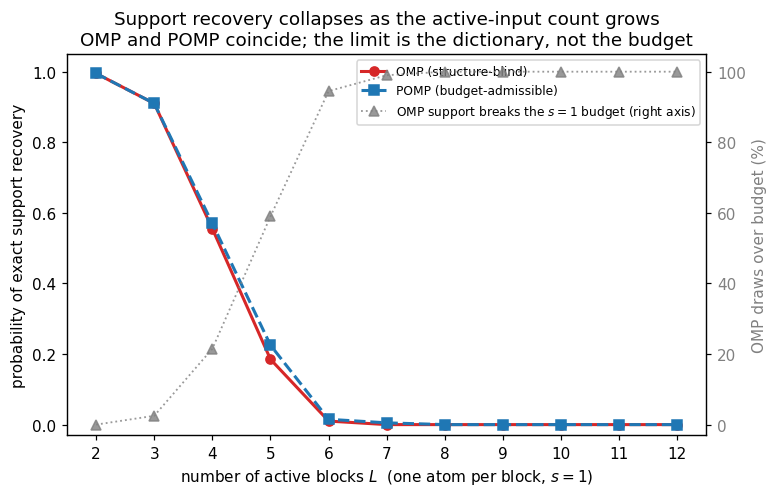

recovery passes 50% between L=4 and L=5
OMP support is budget-inadmissible in 100% of draws from L=8 onward


In [24]:
# Support-recovery phase transition vs L: OMP and POMP on the same axes (they
# coincide), with OMP's budget-inadmissibility annotated on a second axis.
fig, ax = plt.subplots(figsize=(7.5, 4.5))
ax.plot(L_values, rec_omp, 'o-', color='C3', lw=2, label='OMP (structure-blind)')
ax.plot(L_values, rec_pomp, 's--', color='C0', lw=2, label='POMP (budget-admissible)')
ax.set_xlabel('number of active blocks $L$  (one atom per block, $s=1$)')
ax.set_ylabel('probability of exact support recovery')
ax.set_xticks(L_values)
ax.set_ylim(-0.03, 1.05)
ax.set_title('Support recovery collapses as the active-input count grows\n'
             'OMP and POMP coincide; the limit is the dictionary, not the budget')

ax2 = ax.twinx()
ax2.plot(L_values, 100 * omp_inadmissible, '^:', color='gray', lw=1.2, alpha=0.8,
         label='OMP support breaks the $s=1$ budget (right axis)')
ax2.set_ylabel('OMP draws over budget (%)', color='gray')
ax2.tick_params(axis='y', labelcolor='gray')
ax2.set_ylim(-3, 105)

lines1, lab1 = ax.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, lab1 + lab2, loc='upper right', fontsize=8)
plt.savefig(FIGS / 'support_recovery_vs_L.png', dpi=150, bbox_inches='tight')
plt.show()

half = next(L for li, L in enumerate(L_values) if rec_omp[li] < 0.5)
print('recovery passes 50%% between L=%d and L=%d' % (half - 1, half))
print('OMP support is budget-inadmissible in 100%% of draws from L=%d onward'
      % next(L for li, L in enumerate(L_values) if omp_inadmissible[li] == 1.0))

The figure is the central recovery result. There is a clear phase transition in $L$. With two or three active blocks both methods recover the exact support almost always, with probability $0.99$ and $0.91$. Recovery then falls sharply, crossing one half between $L=4$ and $L=5$, dropping to about $0.01$ at $L=6$, and reaching zero by $L=8$. The mean fraction of true atoms recovered tells the same story more smoothly, from $100\%$ at $L=2$ down to about $15\%$ at $L=12$. The transition lives in the number of active blocks, which is the number of active control inputs, exactly the quantity the sparse controllability theory identifies as the governing variable. As the active-input count grows toward the state dimension, the number of distinct supports that explain the target grows with it, and identification becomes impossible even though the target is still reached.

The two recovery curves sit on top of each other. The per-block budget does not lift POMP above OMP, which is the honest result for this dictionary and the reason the curve is drawn with both methods on the same axes rather than one above the other. Every block of $\Phi$ is a full basis, so when the budget forces POMP out of a block it lands on an equally good wrong atom elsewhere. The grey curve is what separates the two methods. It counts how often OMP's recovered support violates the $s=1$ budget, and it rises from zero at $L=2$ to $100\%$ from $L=8$ on. OMP's recovery score is therefore computed on supports that are mostly inadmissible under the actuation budget, while POMP's identical score is computed on supports that always respect it. The two methods recover equally well, but only one of them returns a control the manipulator could run.

#### Recovery under noise

The sweep above is noiseless. The next experiment fixes the difficulty at $L=4$, where recovery is partial rather than saturated, and corrupts the target with additive Gaussian noise at signal-to-noise ratios of 40, 20 and 10 dB. We recover with OMP, POMP and basis pursuit denoising, whose regularization weight is tied to the noise level, and measure the mean fraction of true atoms recovered over 120 seeded trials per setting. This checks whether noise changes the ordering of the methods or only lowers all of them together.

In [25]:
# Mode B under noise: recovery vs SNR at fixed difficulty L=4. OMP, POMP, and
# BPDN (lambda tied to the noise level). BPDN has no support set of its own, so
# we take its L largest-magnitude coefficients as the recovered support.
L_noise = 4
T_N = 120
snr_list = [40, 20, 10]
rec_snr = {m: [] for m in ('OMP', 'POMP', 'BPDN')}
exact_snr = {m: [] for m in ('OMP', 'POMP')}

def bpdn_support(b, lam, k):
    _, coef_n, _, _ = bpdn(b, lam)
    return set(np.argsort(-np.abs(coef_n))[:k].tolist())

for snr_db in snr_list:
    rng_N = np.random.default_rng(7000 + snr_db)
    fo = []; fp = []; fb = []; eo = ep = 0
    for _ in range(T_N):
        c_star, true_sup = draw_known_support(L_noise, 1, rng_N)
        b0 = Phi_n @ c_star
        sig_pow = np.mean(b0 ** 2)
        noise_pow = sig_pow / (10 ** (snr_db / 10))
        b_noisy = b0 + rng_N.normal(0, np.sqrt(noise_pow), size=b0.shape)
        lam = np.sqrt(noise_pow) * np.sqrt(2 * np.log(Phi_n.shape[1]))
        sup_o, _, _ = omp(b_noisy, max_atoms=L_noise, tol=1e-9)
        sup_p, _, _ = pomp(b_noisy, 1, max_atoms=L_noise, tol=1e-9)
        sup_b = bpdn_support(b_noisy, lam, L_noise)
        fo.append(len(set(sup_o) & set(true_sup)) / L_noise)
        fp.append(len(set(sup_p) & set(true_sup)) / L_noise)
        fb.append(len(sup_b & set(true_sup)) / L_noise)
        eo += (set(sup_o) == set(true_sup)); ep += (set(sup_p) == set(true_sup))
    rec_snr['OMP'].append(np.mean(fo)); rec_snr['POMP'].append(np.mean(fp)); rec_snr['BPDN'].append(np.mean(fb))
    exact_snr['OMP'].append(eo / T_N); exact_snr['POMP'].append(ep / T_N)

print('SNR(dB) | mean true atoms recovered          | P(exact)')
print('        | OMP    POMP   BPDN                  | OMP   POMP')
for i, snr_db in enumerate(snr_list):
    print('  %2d    | %.0f%%   %.0f%%   %.0f%%                 | %.2f  %.2f'
          % (snr_db, 100 * rec_snr['OMP'][i], 100 * rec_snr['POMP'][i], 100 * rec_snr['BPDN'][i],
             exact_snr['OMP'][i], exact_snr['POMP'][i]))

SNR(dB) | mean true atoms recovered          | P(exact)
        | OMP    POMP   BPDN                  | OMP   POMP
  40    | 76%   77%   89%                 | 0.55  0.57
  20    | 64%   67%   72%                 | 0.24  0.31
  10    | 49%   50%   48%                 | 0.02  0.04


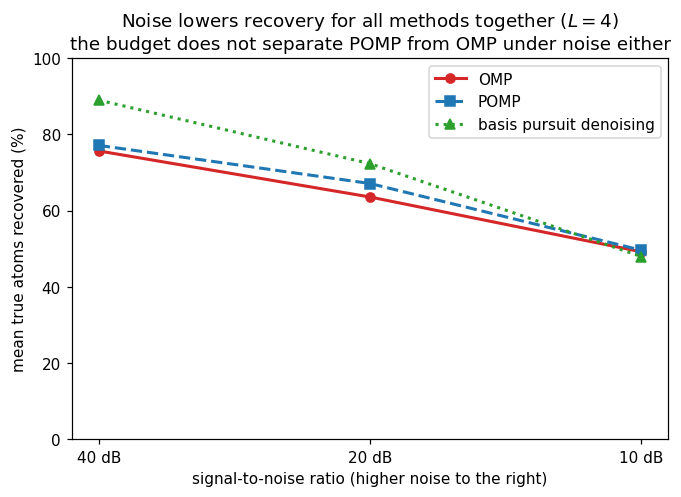

OMP 76->49%, POMP 77->50%, BPDN 89->48% as SNR drops 40->10 dB


In [26]:
# Recovery vs SNR at fixed L=4: OMP, POMP, BPDN. Mean fraction of true atoms.
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(len(snr_list))
ax.plot(x, [100 * v for v in rec_snr['OMP']],  'o-', color='C3', lw=2, label='OMP')
ax.plot(x, [100 * v for v in rec_snr['POMP']], 's--', color='C0', lw=2, label='POMP')
ax.plot(x, [100 * v for v in rec_snr['BPDN']], '^:', color='C2', lw=2, label='basis pursuit denoising')
ax.set_xticks(x)
ax.set_xticklabels(['%d dB' % s for s in snr_list])
ax.set_xlabel('signal-to-noise ratio (higher noise to the right)')
ax.set_ylabel('mean true atoms recovered (%)')
ax.set_ylim(0, 100)
ax.set_title('Noise lowers recovery for all methods together ($L=4$)\n'
             'the budget does not separate POMP from OMP under noise either')
ax.legend()
plt.savefig(FIGS / 'recovery_vs_snr.png', dpi=150, bbox_inches='tight')
plt.show()
print('OMP %.0f->%.0f%%, POMP %.0f->%.0f%%, BPDN %.0f->%.0f%% as SNR drops 40->10 dB'
      % (100 * rec_snr['OMP'][0], 100 * rec_snr['OMP'][-1],
         100 * rec_snr['POMP'][0], 100 * rec_snr['POMP'][-1],
         100 * rec_snr['BPDN'][0], 100 * rec_snr['BPDN'][-1]))

Noise lowers recovery for every method, and it lowers them together. As the signal-to-noise ratio drops from 40 dB to 10 dB the mean fraction of true atoms recovered falls from $76\%$ to $49\%$ for OMP and from $77\%$ to $50\%$ for POMP, with the two essentially indistinguishable at every noise level. Basis pursuit denoising starts higher at $89\%$ in the low-noise case, where its convex global fit helps, but it converges to the same level as the greedy methods at 10 dB. Noise does not create a regime where the budget helps identification. It makes every wrong block look a little more like the right one, which hurts all methods equally and does not change their ordering. This confirms the earlier reading from a second direction: on this dictionary the limit on recovery is the geometry of $\Phi$, and the per-block budget changes feasibility, not identifiability.

### Method comparison at a fixed budget

The experiments are summarized in one table at a fixed budget $s=2$, drawn on the noiseless synthetic problem at $L=4$ so that a true support exists and the oracle is a genuine lower bound rather than a fit on a found support. The table reports the median over the same 200 seeded trials. It collects the four quantities the report cares about: control energy, reconstruction residual, exact support recovery, and per-target runtime.

In [27]:
# Summary table at fixed s=2 on the synthetic L=4 problem (true support exists,
# so the oracle is a real lower bound). Median over 200 seeded trials.
L_tab, s_tab, T_tab = 4, 2, 200
rng_tab = np.random.default_rng(2024)
rows = {m: {'energy': [], 'resid': [], 'exact': 0, 'time': []}
        for m in ('OMP', 'POMP', 'basis pursuit', 'oracle-LS')}
for _ in range(T_tab):
    c_star, true_sup = draw_known_support(L_tab, s_tab, rng_tab)   # up to L*s=8 atoms <= 25
    b_syn = Phi_n @ c_star
    # OMP
    t0 = time.perf_counter(); sup_o, c_o, r_o = omp(b_syn, max_atoms=L_tab * s_tab, tol=1e-12); to = time.perf_counter() - t0
    rows['OMP']['energy'].append(energy(c_o)); rows['OMP']['resid'].append(r_o)
    rows['OMP']['exact'] += (set(sup_o) == set(true_sup)); rows['OMP']['time'].append(to)
    # POMP
    t0 = time.perf_counter(); sup_p, c_p, r_p = pomp(b_syn, s_tab, max_atoms=L_tab * s_tab, tol=1e-12); tp = time.perf_counter() - t0
    rows['POMP']['energy'].append(energy(c_p)); rows['POMP']['resid'].append(r_p)
    rows['POMP']['exact'] += (set(sup_p) == set(true_sup)); rows['POMP']['time'].append(tp)
    # basis pursuit
    t0 = time.perf_counter(); c_b, cn_b, r_b, _ = basis_pursuit(b_syn); tb = time.perf_counter() - t0
    sup_b = set(np.argsort(-np.abs(cn_b))[:len(true_sup)].tolist())
    rows['basis pursuit']['energy'].append(energy(c_b)); rows['basis pursuit']['resid'].append(r_b)
    rows['basis pursuit']['exact'] += (sup_b == set(true_sup)); rows['basis pursuit']['time'].append(tb)
    # oracle on the TRUE support
    t0 = time.perf_counter(); c_or, r_or = oracle_ls(b_syn, true_sup); tor = time.perf_counter() - t0
    rows['oracle-LS']['energy'].append(energy(c_or)); rows['oracle-LS']['resid'].append(r_or)
    rows['oracle-LS']['exact'] += 1; rows['oracle-LS']['time'].append(tor)

print('synthetic problem: L=%d active blocks, s=%d, %d trials, true support <= %d atoms'
      % (L_tab, s_tab, T_tab, L_tab * s_tab))
print('%-16s | %-10s | %-10s | %-12s | %-10s'
      % ('method', 'energy', 'residual', 'exact rec.', 'time (ms)'))
for m in ('OMP', 'POMP', 'basis pursuit', 'oracle-LS'):
    print('%-16s | %-10.4f | %-10.2e | %-12s | %-10.3f'
          % (m, np.median(rows[m]['energy']), np.median(rows[m]['resid']),
             '%.0f%%' % (100 * rows[m]['exact'] / T_tab), 1e3 * np.median(rows[m]['time'])))

synthetic problem: L=4 active blocks, s=2, 200 trials, true support <= 8 atoms
method           | energy     | residual   | exact rec.   | time (ms) 
OMP              | 1.1866     | 2.97e-01   | 4%           | 0.172     
POMP             | 1.1191     | 3.20e-01   | 4%           | 0.185     
basis pursuit    | 1.1810     | 6.65e-14   | 2%           | 13.514    
oracle-LS        | 1.2540     | 2.28e-15   | 100%         | 0.028     


The table collects the whole comparison. On residual the convex method and the oracle reach machine precision, while the greedy methods stop at about $0.3$ because they are capped at the eight-atom budget and, on a problem this hard, those eight atoms do not include the full true support. On energy the four methods are close, between $1.12$ and $1.25$, with POMP marginally the cheapest of the practical methods. The oracle energy is actually the highest of the four, which looks odd until one remembers what the oracle is: it is least squares on the true support, not the globally cheapest fit. The other methods reach a lower energy by landing on a different, lower-energy support that also fits the target, which is the same fact that makes recovery hard here.

The recovery column is the one that matters and it is stark. Handed the true support, the oracle recovers it by definition, $100\%$. None of the practical methods come close: OMP and POMP both recover the exact support in $4\%$ of trials and basis pursuit in $2\%$. This is the lesson of the whole recovery study in one line. Fitting the target is easy and every method does it, but recovering the support that generated the target is hard, and on this dictionary no method we have, structured or not, does it reliably once the active-input count is more than a handful. The runtime column repeats the Mode A finding: the greedy methods cost a fraction of a millisecond, the convex solve costs about eighty times more, and the oracle is fastest because it solves a single least squares on a known support.

### What the experiments show

The experiments answer the three questions the project set out with. On the energy and sparsity tradeoff, the budget does not decide whether a target is reachable, since every budget down to $s=1$ reaches it far below the feasibility threshold, but it does decide the cost. POMP's median energy falls from $7.96$ at $s=1$ to $4.71$ at $s=5$ and converges toward the unconstrained OMP energy as the budget stops binding. The per-step view sharpens this: control concentrates at the final steps, where it acts on the state directly, and a tighter budget forces the manipulator to recruit earlier steps where its influence is weaker. A smaller budget therefore costs more energy and demands earlier action.

On the value of structure, POMP earns its place on feasibility rather than on energy or recovery. It is the only method that returns a control respecting the per-step budget. OMP and basis pursuit reach lower energy, but they do so with schedules that put many nodes into one step, which OMP's recovered support did in every draw once $L$ reached eight. Their lower energy is the energy of a control that could not actually be run. POMP matches the greedy baseline on every other axis at no runtime penalty, and it is the only one of the three that is feasible.

On recovery limits, the phase transition lives in the number of active blocks, not the budget. Exact recovery is almost certain for two or three active blocks, crosses one half between four and five, and is effectively zero by eight, both noiseless and under noise. This matches the sparse controllability theory, where the governing quantity is the number of active inputs rather than the per-step budget, and it explains why the budget cannot lift recovery on this operator: every block of $\Phi$ is a full basis, so a wrong support fits the target as well as the right one, and constraining where atoms may go does not make the right atoms identifiable. The honest summary is that the structure buys a feasible, low-energy control, and that recovery is bounded by the dictionary geometry, which a per-block budget cannot change.

## Discussion

This section pulls the experiments together into the answers to the four
questions the project set out with, and ties the recovery result back to the
controllability theory. It adds no new computation beyond a typeset version of
the comparison table and one small counterfactual. Everything else is the
results already in hand.

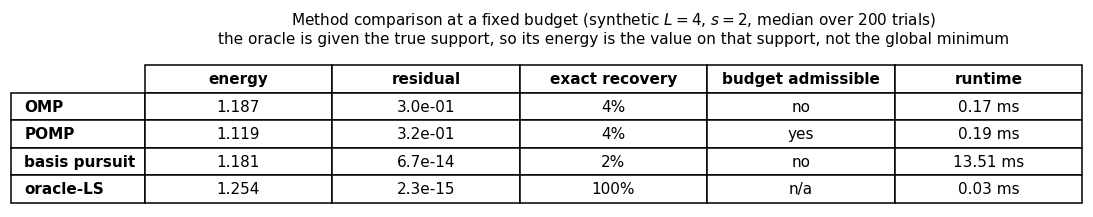

,control energy $\Vert u\Vert_2$,residual $\Vert b-\Phi u\Vert_2$,exact support recovery,per-block budget admissible,runtime per target
method,,,,,
OMP,1.187,3.0e-01,4%,no,0.17 ms
POMP,1.119,3.2e-01,4%,yes,0.19 ms
basis pursuit,1.181,6.7e-14,2%,no,13.51 ms
oracle-LS,1.254,2.3e-15,100%,n/a,0.03 ms


In [28]:
# Typeset the fixed-budget comparison as a table (it was printed as text above).
# Numbers come straight from the L=4, s=2 synthetic experiment already run; this
# only reshapes the medians in `rows` into a labelled table for the report.
import pandas as pd

methods = ['OMP', 'POMP', 'basis pursuit', 'oracle-LS']
comparison = pd.DataFrame({
    'control energy $\\Vert u\\Vert_2$': [np.median(rows[m]['energy']) for m in methods],
    'residual $\\Vert b-\\Phi u\\Vert_2$': [np.median(rows[m]['resid']) for m in methods],
    'exact support recovery': [rows[m]['exact'] / T_tab for m in methods],
    'per-block budget admissible': ['no', 'yes', 'no', 'n/a'],
    'runtime per target': [np.median(rows[m]['time']) for m in methods],
}, index=methods)

# rendered, human-readable view
show = comparison.copy()
show['control energy $\\Vert u\\Vert_2$'] = show['control energy $\\Vert u\\Vert_2$'].map('{:.3f}'.format)
show['residual $\\Vert b-\\Phi u\\Vert_2$'] = show['residual $\\Vert b-\\Phi u\\Vert_2$'].map('{:.1e}'.format)
show['exact support recovery'] = show['exact support recovery'].map('{:.0%}'.format)
show['runtime per target'] = (1e3 * show['runtime per target']).map('{:.2f} ms'.format)
show.index.name = 'method'

# save the same table as a standalone figure for the report and slides
fig, ax = plt.subplots(figsize=(11, 1.7))
ax.axis('off')
tbl = ax.table(cellText=show.values,
               colLabels=['energy', 'residual', 'exact recovery',
                          'budget admissible', 'runtime'],
               rowLabels=show.index, cellLoc='center', loc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1, 1.5)
for (r_, c_), cell in tbl.get_celld().items():
    if r_ == 0 or c_ == -1:
        cell.set_text_props(fontweight='bold')
ax.set_title('Method comparison at a fixed budget (synthetic $L=4$, $s=2$, '
             'median over 200 trials)\nthe oracle is given the true support, '
             'so its energy is the value on that support, not the global minimum',
             fontsize=10, pad=12)
plt.savefig(FIGS / 'method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

show

The table separates the four methods on the axes that matter. On residual,
basis pursuit and the oracle hit the target to numerical zero ($\sim 10^{-14}$),
while the greedy methods sit at about $0.3$ at this difficulty because at $L=4$
they often land on a support that is close but not exact. On energy the
numbers are close: the three practical methods are within about six percent of
each other and the oracle sits about twelve percent above the cheapest. The two
axes that actually separate them are
the last two columns. POMP is the only method whose recovered control respects
the per-block budget. OMP and basis pursuit both return controls that put more
than $s$ nodes into a single step, so their numbers describe schedules that could
not be run under the actuation limit. On exact support recovery the two greedy
methods tie at $4\%$ and basis pursuit is lower at $2\%$, all far below the
oracle.

The oracle row needs one caveat that the caption also carries. Its energy
($1.254$) is the highest of the four, not the lowest. That is not the oracle
being beaten. The oracle solves least squares on the true support, so its energy
is the cost of the correct control, while the practical methods reach slightly
lower energy by sitting on a different support that also fits $b$. That a wrong
support can be cheaper than the right one is the same fact that makes recovery
hard here. The oracle remains the benchmark it is meant to be: exact recovery by
construction and the residual lower bound at $\sim 10^{-15}$.

In [29]:
# Small aggregation for the tradeoff narrative. No new sweeps: this reuses the
# Mode A arrays (pomp_energy, omp_energy) and the per-step profiles already in
# memory, and just reports the few summary numbers the discussion refers to.
e1, e5 = np.median(pomp_energy[1]), np.median(pomp_energy[5])
iqr1 = np.percentile(pomp_energy[1], [25, 75])
iqr5 = np.percentile(pomp_energy[5], [25, 75])
first_step_saving = np.median(pomp_energy[1]) - np.median(pomp_energy[2])
total_saving = np.median(pomp_energy[1]) - np.median(pomp_energy[5])

print('POMP median energy: s=1 %.2f -> s=5 %.2f (OMP reference %.2f)'
      % (e1, e5, np.median(omp_energy)))
print('IQR width: s=1 %.2f -> s=5 %.2f' % (iqr1[1] - iqr1[0], iqr5[1] - iqr5[0]))
print('energy saved by the first budget increment (s=1->2): %.2f of %.2f total (s=1->5)'
      % (first_step_saving, total_saving))
print('fraction of the total saving captured in the first increment: %.0f%%'
      % (100 * first_step_saving / total_saving))
print('residual range across the sweep: %.1e (s=1) .. %.1e (s=5), threshold xi ~ %.2f'
      % (np.median(pomp_resid[1]), np.median(pomp_resid[5]),
         1e-2 * np.median([np.linalg.norm(B_targets[i]) ** 2 for i in idx_A])))
print('last-3-step energy share: OMP %.0f%%, POMP s=1 %.0f%%, POMP s=3 %.0f%%'
      % (100 * prof_omp[-3:].sum() / prof_omp.sum(),
         100 * prof_p1[-3:].sum() / prof_p1.sum(),
         100 * prof_p3[-3:].sum() / prof_p3.sum()))

POMP median energy: s=1 7.96 -> s=5 4.71 (OMP reference 4.28)
IQR width: s=1 9.40 -> s=5 2.00
energy saved by the first budget increment (s=1->2): 1.58 of 3.25 total (s=1->5)
fraction of the total saving captured in the first increment: 49%
residual range across the sweep: 7.8e-10 (s=1) .. 9.8e-15 (s=5), threshold xi ~ 0.24
last-3-step energy share: OMP 100%, POMP s=1 81%, POMP s=3 97%


### The sparsity and energy tradeoff

The first question was how control energy changes with the per-step budget and
how the control mass is spread across time. Feasibility turned out not to be the
variable. Every budget from $s=1$ upward reaches the target with a residual
around $10^{-9}$ to $10^{-14}$, roughly ten orders of magnitude below the
feasibility threshold $\xi$, so the budget does not decide whether the network
can be driven to the target. It decides the cost. POMP's median energy falls
monotonically from $7.96$ at $s=1$ to $4.71$ at $s=5$ and the spread tightens
with it, from an interquartile width near $9.4$ at $s=1$ to about $2.0$ at $s=5$.
A looser budget is both cheaper and more consistent across targets. The energy
curve converges downward toward the budget-blind OMP median of $4.28$, because
POMP is OMP plus a per-block cap: as $s$ grows the cap binds on fewer targets,
and once it never binds POMP's feasible set contains OMP's choice and the two
agree. The gap between the POMP curve and the OMP line at each $s$ is therefore
exactly the price of enforcing the budget, and it shrinks to zero as the budget
loosens.

The saving is front-loaded. Most of the energy reduction is bought by the first
one or two increments of $s$, after which the curve flattens. The practical
reading is that the first relaxation of a tight budget is worth the most, and a
manipulator gains little by widening an already-loose budget.

The per-step profile completes the picture. Left unconstrained, control collapses
onto the final steps: OMP places essentially all of its energy in the last three
steps. The reason is geometric. A control applied at the final step acts on the
state directly through the identity block, whereas a control applied early must
pass through a high power of $A$, which after normalization aligns far less
cleanly with the target. Greedy prefers the final step. The budget changes this.
Forbidden from piling mass onto the last step, POMP at $s=1$ is forced to recruit
earlier, weaker steps, and the last-three-step share drops to $81\%$ while the
final-step energy actually rises. At $s=3$ the method concentrates again, back to
$97\%$. So a tighter budget does two things at once: it raises the total energy
and it pushes the control earlier in time, when the manipulator's influence on
the final state is weaker.

### What the structure is worth

The second question was whether exploiting the piecewise structure beats
structure-blind recovery. The honest answer needs three axes kept separate,
because the structured method wins on two of them and ties on the third.

On feasibility under the budget, POMP wins outright, and at population scale.
The per-step budget is a hard physical constraint, since the manipulator can
touch at most $s$ nodes per step. POMP is the only method in the set that returns
a control satisfying it. Across the recovery sweep, OMP's recovered support
breaks the $s=1$ cap in a fraction that climbs from $0\%$ at $L=2$ to $100\%$
from $L=8$ on, while POMP's support respects the cap in every draw by
construction. On most of the regime OMP's output is not a control the manipulator
could execute. Basis pursuit is worse still, piling up to 17 nodes into one step
on a given target. A method that returns an admissible schedule is doing
something the others cannot, regardless of their energy numbers.

On energy among feasible controls, POMP also wins, because it is the only
feasible method. Its energy falls with $s$ as shown above, and that is the
cheapest schedule that actually respects the budget. The lower energies reported
by OMP and basis pursuit are the energies of inadmissible schedules, so they are
a lower bound no deployable controller can claim, not a fair competitor.

On exact support recovery, POMP ties OMP and does not win. Both recover the same
fraction of the planted atoms at every difficulty, and the summary table shows
them equal at $4\%$. The cause is the structure of the dictionary, not a defect
of the method. Because $A$ is invertible, every block of $\Phi$ is a full basis
for $\mathbb{R}^{25}$, so a wrong support explains the target as well as the right
one. Constraining where atoms may go does not make the right atoms identifiable
when every location fits the residual equally well. The one thing the tie does
not erase is admissibility: POMP's tied score sits on a budget-respecting
support, OMP's on a support that violates the budget in nearly every draw. So the
case for structure is feasibility, feasible-optimal energy, and a controllable
temporal profile, and we are explicit that recovery is not one of the wins on
this operator.

### Recovery limits and the controllability bound

The third question was where exact support recovery breaks down, and the fourth
was whether that matches the sparse controllability theory. The two are answered
together, because the empirical breakdown is the signature of the quantity the
theory points to.

The recovery experiment varies the number of active blocks $L$ at $s=1$, which is
the number of control inputs active over the horizon. It shows a clean phase
transition. Exact recovery is almost certain for two or three active blocks
($0.99$ at $L=2$, $0.91$ at $L=3$), crosses one half between $L=4$ and $L=5$
($0.56$ then $0.18$), and is effectively zero by $L=8$. The mean fraction of true
atoms recovered decays the same way. The noise sweep at fixed $L=4$ lowers every
method together as the signal-to-noise ratio drops, and never separates POMP from
OMP, so the failure is geometric rather than driven by noise: noise blurs a
geometry that is already degenerate. The complementary control is just as
informative. Sweeping the per-step budget $s$ does not move recovery at all on
this operator, only $L$ does. The governing variable is the number of active
inputs, not the size of the per-step budget.

This is exactly what the sparse controllability theory predicts. Joseph and
Murthy study controllability of linear systems under input sparsity and give
algebraic conditions together with the *minimum number of active input vectors*
needed to reach a target, with a Kalman-like decomposition into
sparse-controllable and sparse-uncontrollable subspaces. The companion work of
Joseph, Nettasinghe, Krishnamurthy and Varshney casts opinion manipulation on a
network in the same terms. The quantity those results turn on is how many input
vectors are active, not how large the per-step budget is. The reframing in this
project makes the correspondence direct: an active block of $\Phi$ is an active
control input, so the number of active blocks $L$ is the number of active inputs,
and the per-block budget $s$ is the within-step actuation count, a different
quantity. The theory says a small active-input count is benign and that the
problem becomes ill-posed as the active-input count approaches the state
dimension. Our transition is the empirical instance of that statement: at small
$L$ the support is identifiable, and as $L$ climbs toward $n=25$ the number of
supports that reach the same target multiplies until identification is
impossible, even though reaching the target never fails.

We do not claim a single theorem with $L=4$ as a sharp constant. The theory
gives the governing quantity and the direction of failure, and the experiment
gives where the transition sits for this particular $A$. The two agree on the
quantity that matters, the direction of the effect, and the controls: $s$ has no
effect and noise only blurs the geometry, both of which the active-input reading
predicts and the per-step-budget reading does not. That is the level of match a
short study can support, and it is the one the data shows.

### Complexity and runtime

The three methods fall into two complexity classes. OMP and POMP are greedy: each
iteration is one correlation pass over the $25 \times 625$ dictionary followed by
a small least-squares solve on the current support, and the loop runs for at most
$K$ iterations, with $K \le 25$ here. POMP adds only a per-block counter and an
early exit when a block fills, which is constant-time bookkeeping per iteration,
so it has the same per-iteration order as OMP. The measured runtimes confirm
this: both run in about a millisecond per target across the whole budget sweep,
with POMP no slower than OMP in any meaningful sense. The budget guarantee
therefore comes at no runtime cost over the structure-blind greedy method, which
is part of why POMP is the right choice. Basis pursuit is a different class. It
solves a conic program over all 625 variables with an interior-point method, and
it is about an order of magnitude slower than the greedy methods. For a problem
solved repeatedly over many targets and budgets, the greedy methods are the
practical choice, and POMP is the one to use because it is the only greedy method
that respects the budget. The absolute timings and the exact basis-pursuit ratio
drift from run to run, so the comparison is stated qualitatively: about a
millisecond for the greedy methods, roughly an order of magnitude more for the
convex solver.

In [30]:
# Counterfactual: what if A were stable (spectral radius < 1) instead of rho=6.08?
# A small illustration, not a re-run of the study. We build one synthetic stable
# matrix with the same eigenvector geometry as A but eigenvalues scaled inside the
# unit circle, then compare the per-block column-scale spread and conditioning.
rho_A = max(abs(np.linalg.eigvals(A)))
w, V = np.linalg.eig(A)
w_stable = 0.9 * w / np.max(np.abs(w))               # same directions, rho = 0.9
A_stable = np.real(V @ np.diag(w_stable) @ np.linalg.inv(V))

def block_scale_spread(M):
    powers = []
    Pk = np.eye(N)
    for _ in range(N):                               # A^0 .. A^(N-1)
        powers.append(Pk.copy()); Pk = Pk @ M
    powers = powers[::-1]                             # block 0 = A^(N-1), last = I
    Phi_M = np.hstack(powers)
    col = np.linalg.norm(Phi_M, axis=0)
    med = np.array([np.median(col[j * N:(j + 1) * N]) for j in range(N)])
    return Phi_M, col, med

Phi_s, col_s, med_s = block_scale_spread(A_stable)
_, col_u, med_u = block_scale_spread(A)              # the real A, for reference

print('spectral radius: real A %.3f, synthetic stable A %.3f' % (rho_A, max(abs(w_stable))))
print('real A      : block 0 (A^24) median col-norm %.2e, identity block %.2e, ratio %.2e'
      % (med_u[0], med_u[-1], med_u[0] / med_u[-1]))
print('stable A    : block 0 (A^24) median col-norm %.2e, identity block %.2e, ratio %.2e'
      % (med_s[0], med_s[-1], med_s[0] / med_s[-1]))
print('which block is the LARGEST-scale one: real A block %d, stable A block %d'
      % (int(np.argmax(med_u)), int(np.argmax(med_s))))

# conditioning after the same unit-norm fix
Phi_sn = Phi_s / col_s
print('cond(Phi) stable A: raw %.2e -> unit-norm %.2f' % (np.linalg.cond(Phi_s), np.linalg.cond(Phi_sn)))

# Does the final-step concentration survive a stable A? The dataset targets were
# generated under the real A, so for the stable operator we test on generic
# reachable targets (random unit-direction b, comparable norm) and recover with a
# small local OMP on its own normalized dictionary.
def local_omp(Phn, scale, b, K=N):
    r = b.astype(float).copy(); sup = []
    for _ in range(K):
        corr = np.abs(Phn.T @ r)
        if sup: corr[sup] = 0.0
        j = int(np.argmax(corr)); sup.append(j)
        coef, *_ = np.linalg.lstsq(Phn[:, sup], b, rcond=None)
        r = b - Phn[:, sup] @ coef
        if np.linalg.norm(r) < 1e-10: break
    full = np.zeros(Phn.shape[1]); full[sup] = coef / scale[sup]
    return full

def step_profile(full):                              # ||u_k|| vs k, k=1..N
    return np.array([np.linalg.norm(full[k * N:(k + 1) * N]) for k in range(N)])

gen_rng = np.random.default_rng(7)
prof_stable = np.zeros(N)
for _ in range(60):
    b_gen = gen_rng.standard_normal(N); b_gen *= 5.0 / np.linalg.norm(b_gen)
    prof_stable += step_profile(local_omp(Phi_sn, col_s, b_gen))
prof_stable /= 60
print('stable A, generic targets: last-3-step energy share %.0f%%, first-3-step share %.0f%%'
      % (100 * prof_stable[-3:].sum() / prof_stable.sum(),
         100 * prof_stable[:3].sum() / prof_stable.sum()))


spectral radius: real A 6.078, synthetic stable A 0.900
real A      : block 0 (A^24) median col-norm 2.55e+18, identity block 1.00e+00, ratio 2.55e+18
stable A    : block 0 (A^24) median col-norm 3.15e-02, identity block 1.00e+00, ratio 3.15e-02
which block is the LARGEST-scale one: real A block 0, stable A block 24
cond(Phi) stable A: raw 3.33e+00 -> unit-norm 16.67
stable A, generic targets: last-3-step energy share 47%, first-3-step share 0%


### What a different operator would change

The whole numerical story here is driven by $A$ being strongly unstable, with
spectral radius $6.08$. That is what makes the early control blocks explode: the
block holding $A^{24}$ has a median column norm about eighteen orders of
magnitude larger than the identity block, so without normalization greedy
selection is decided by scale rather than relevance. The small illustration above
inverts the spectrum into the unit circle while keeping the same eigenvector
directions. With a stable $A$ the powers $A^p$ shrink instead of growing, so the
direction of the scale spread flips: the early blocks become the small ones and
the identity block becomes the largest. But the size of the spread does not stay
the same, it collapses. The spread is set by $\rho^{N-1}$, which is about
$10^{18}$ at $\rho=6.08$ but only about $0.9^{24}\approx 0.08$ at $\rho=0.9$, so
the stable case spans barely one and a half orders of magnitude (a block-scale
ratio near $32$) rather than eighteen. The conditioning reflects this: the stable
dictionary has a raw condition number of about $3.3$, already well conditioned,
where the real one is $\sim\!10^{16}$. So the pathology is not symmetric. It is
severe only when $\rho$ is far from one and the powers run away, which the real
unstable $A$ does and a mildly stable $A$ does not. Unit-norm normalization is
still the right general step and brings both to the same conditioning, but on the
stable operator it is no longer load bearing the way it is here.

One thing does not change: where the control sits in time. It would be tempting
to say that with the scale spread reversed the cheap controls move to the start
and the mass concentrates early, but the small check above shows the opposite.
On generic targets the stable operator still piles its control into the final
steps (last-three-step share about half, first-three-step share zero), the same
qualitative picture as the real $A$. The reason is that the concentration is not
a scale effect at all. After unit-norm normalization every column has the same
length, and a control placed at the final step represents the target directly
through the identity block, whereas any earlier control must reach the target
through a power of $A$ and aligns less cleanly. That geometry is preserved by the
normalization for any spectral radius, so greedy keeps preferring the final step
whether $A$ is unstable or stable. What the spectral radius controls is the
conditioning, not the temporal profile.

A non-invertible $A$ would change something deeper than scale. The reason the
budget cannot improve support recovery here is that every block of $\Phi$ is a
full basis, which holds precisely because $A$ is invertible. If $A$ were singular,
its powers would lose rank and the blocks would no longer each span
$\mathbb{R}^{25}$. A target might then be reachable only through specific blocks,
so a wrong block could not replicate the right one, and the per-block budget would
start to carry identifying information. In that regime the budget could bind on
identification and steer greedy toward the true support, which is the one setting
where exploiting the structure would also raise recovery. On this operator that
condition does not hold, which is why the recovery result reads as a controlled
negative finding tied to the geometry of $A$, rather than a gap in the method.

### Conclusion

Reframing the control problem as piecewise-sparse recovery gives a clear set of
answers. Feasibility is free on this network: with twenty-five steps and a budget
of one node per step there are already enough degrees of freedom to hit any
target, so the per-step budget is not a feasibility knob but an energy and timing
knob. Tightening it raises the control energy and pushes the control earlier in
time, with the largest cost in the first increment and a price that vanishes as
the budget loosens and the structured method relaxes into the unconstrained one.
The piecewise structure earns its place on feasibility and on feasible-optimal
energy, since POMP is the only method that returns a control respecting the
actuation budget, at no runtime cost over structure-blind greedy. It does not
raise support recovery on this operator, and that is a property of the dictionary
geometry rather than the method: every block is a full basis, so a wrong support
fits as well as the right one. Where recovery does break down, the boundary is
set by the number of active inputs, not the per-step budget, with a phase
transition between four and five active blocks that matches the sparse
controllability theory's reliance on the active-input count.

One modelling assumption remains open. We take $x_0 = 0$, so the target is the
final state itself, because the dataset provides only $A$ and the final states. A
nonzero initial state would shift the target by $A^N x_0$, a term of order
$10^{19}$ that would dominate everything, so the assumption is not innocuous and
should be confirmed with the consultant before the final write-up. Every other
input to the study is fixed by the data.